In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import sklearn.metrics as mt

C:\ProgramData\Anaconda3\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
df =pd.read_csv("diabetes_early_prediction.csv")

In [3]:
df.head(5)

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 520 non-null    int64 
 1   Gender              520 non-null    object
 2   Polyuria            520 non-null    object
 3   Polydipsia          520 non-null    object
 4   sudden weight loss  520 non-null    object
 5   weakness            520 non-null    object
 6   Polyphagia          520 non-null    object
 7   Genital thrush      520 non-null    object
 8   visual blurring     520 non-null    object
 9   Itching             520 non-null    object
 10  Irritability        520 non-null    object
 11  delayed healing     520 non-null    object
 12  partial paresis     520 non-null    object
 13  muscle stiffness    520 non-null    object
 14  Alopecia            520 non-null    object
 15  Obesity             520 non-null    object
 16  class               520 no

In [5]:
df.shape

(520, 17)

In [6]:
df.columns

Index(['Age', 'Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss',
       'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring',
       'Itching', 'Irritability', 'delayed healing', 'partial paresis',
       'muscle stiffness', 'Alopecia', 'Obesity', 'class'],
      dtype='object')

In [7]:
df.describe(include="all")

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
count,520.000000,520,520,520,520,520,520,520,520,520,520,520,520,520,520,520,520
unique,NaN,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
top,NaN,Male,No,No,No,Yes,No,No,No,No,No,No,No,No,No,No,Positive
freq,NaN,328,262,287,303,305,283,404,287,267,394,281,296,325,341,432,320
mean,48.028846,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,12.151466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,16.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,39.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,47.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,57.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df['class'].value_counts()

Positive    320
Negative    200
Name: class, dtype: int64

In [9]:
df.isnull().Age

0      False
1      False
2      False
3      False
4      False
       ...  
515    False
516    False
517    False
518    False
519    False
Name: Age, Length: 520, dtype: bool

In [10]:
df.duplicated().sum()

269

In [11]:
df.isnull().sum()

Age                   0
Gender                0
Polyuria              0
Polydipsia            0
sudden weight loss    0
weakness              0
Polyphagia            0
Genital thrush        0
visual blurring       0
Itching               0
Irritability          0
delayed healing       0
partial paresis       0
muscle stiffness      0
Alopecia              0
Obesity               0
class                 0
dtype: int64

In [12]:
df.nunique()


Age                   51
Gender                 2
Polyuria               2
Polydipsia             2
sudden weight loss     2
weakness               2
Polyphagia             2
Genital thrush         2
visual blurring        2
Itching                2
Irritability           2
delayed healing        2
partial paresis        2
muscle stiffness       2
Alopecia               2
Obesity                2
class                  2
dtype: int64

In [13]:
#Replacee capital letter to small letter and also replace attribute names gap with the hypen
df.columns = map(str.lower, df.columns)
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")

In [14]:
df.head()

,age,gender,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


In [15]:
#level the catagorical data to numeric data using labelencoder and minmaxscaler
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
label_encoder = LabelEncoder()
for column in df.columns:
    df[column] = label_encoder.fit_transform(df[column])
df.head(5)

,age,gender,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity,class
0,16,1,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,34,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,17,1,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,21,1,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,36,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


In [16]:
df.sample(5)

,age,gender,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity,class
460,23,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0
228,21,1,0,0,0,1,0,0,0,1,1,1,1,0,0,0,0
515,15,0,1,1,1,0,1,0,0,1,0,1,1,0,0,0,1
210,15,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0
46,36,0,1,1,1,1,1,0,1,1,0,1,1,1,0,1,1


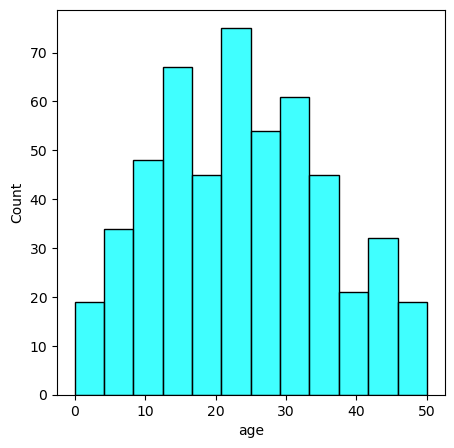

In [17]:
plt.figure(figsize=(5,5))

x = sns.histplot(df["age"], color="Cyan")

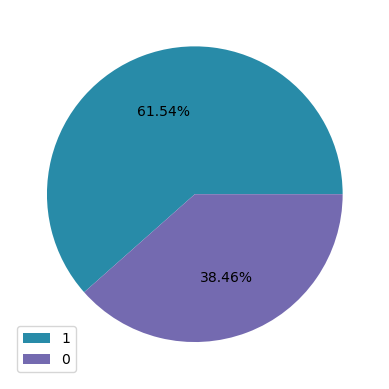

In [18]:
counts = df["class"].value_counts()
colors = ['#288BA8', '#746AB0'] 
plt.pie(counts, autopct="%0.2f%%",colors=colors)
plt.legend(counts.index)
plt.show()

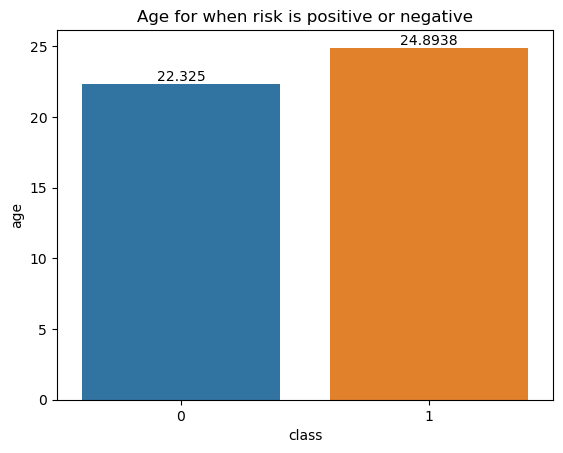

In [19]:
groupby = df.groupby("class")
fig, axes = plt.subplots()
means = groupby["age"].mean()
sns.barplot(x=means.index, y=means, ax=axes)
for container in axes.containers:
    axes.bar_label(container)
    
plt.title("Age for when risk is positive or negative")
plt.show()

In [20]:
def category(column):
    colors = ['#288BA8', '#746AB0'] 
    unique_vals = df[column].unique()
    temp_df = df[df[column] == unique_vals[0]].copy()
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
    counts = temp_df["class"].value_counts()
    axes[0].pie(counts, autopct="%0.2f%%",colors=colors)
    axes[0].legend(counts.index)
    axes[0].set_title("Diabetes ratio when {} is {}".format(column, unique_vals[0]))
    
    temp_df = df[df[column] == unique_vals[1]].copy()
    counts = temp_df["class"].value_counts()
    axes[1].pie(counts, autopct="%0.2f%%",colors=colors)
    axes[1].legend(counts.index)
    axes[1].set_title("Diabetes ratio when {} is {}".format(column, unique_vals[1]))
    plt.tight_layout()
    plt.show()

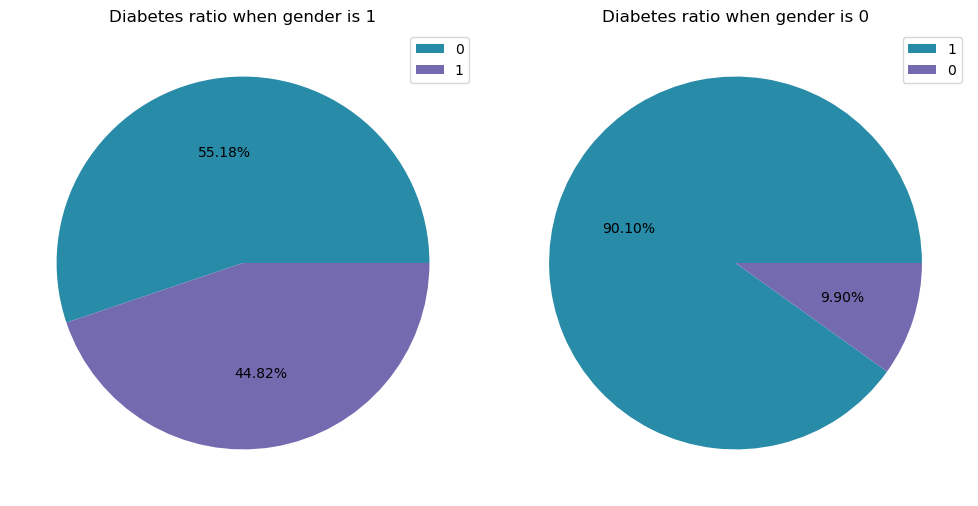

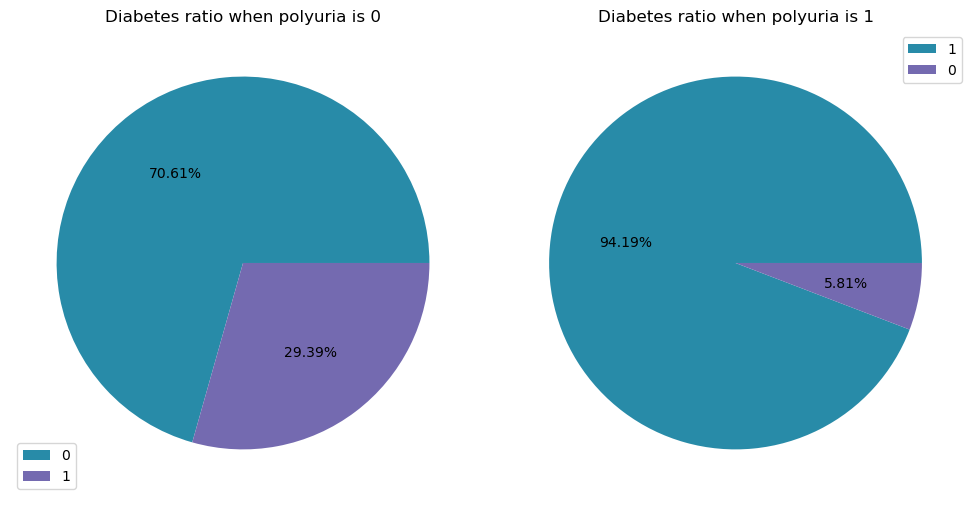

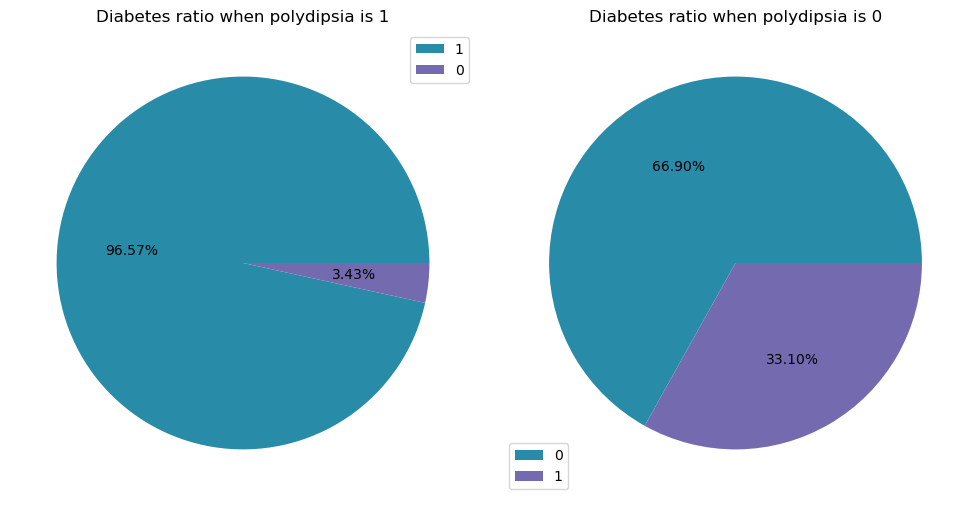

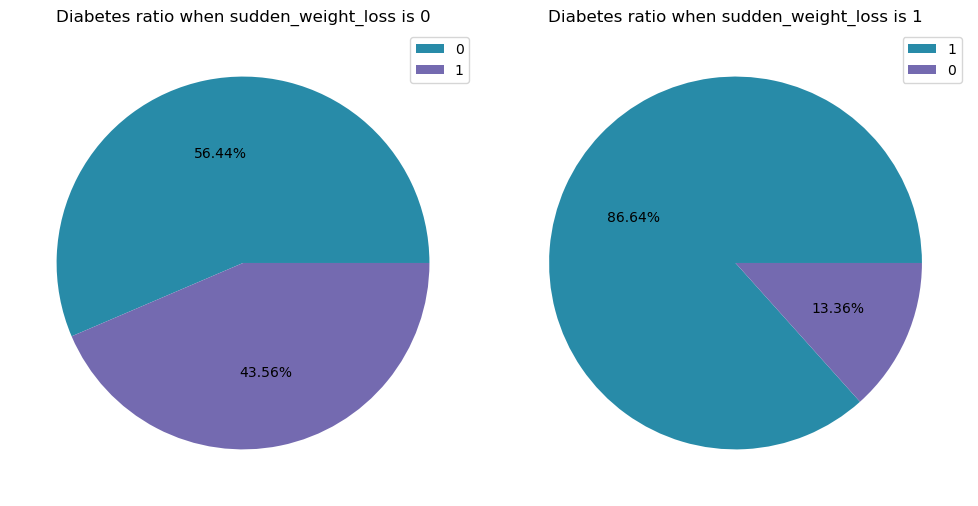

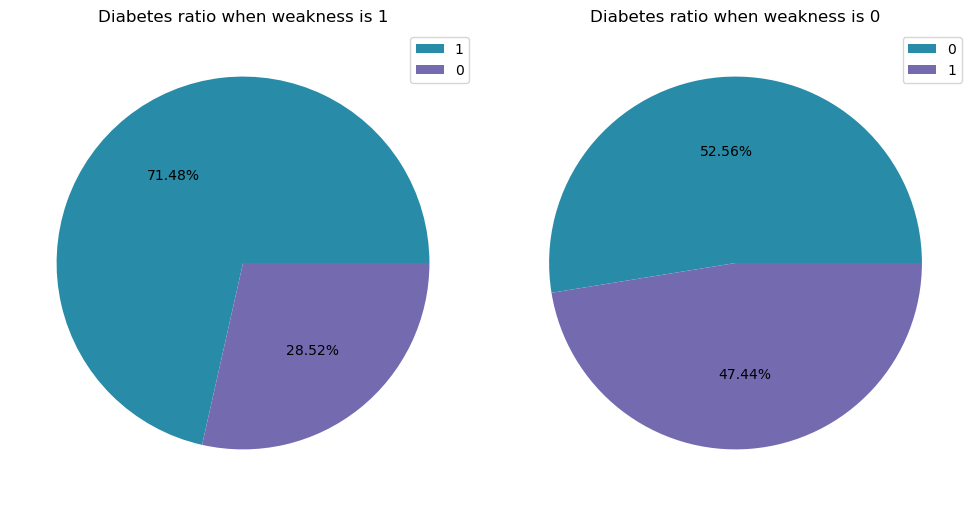

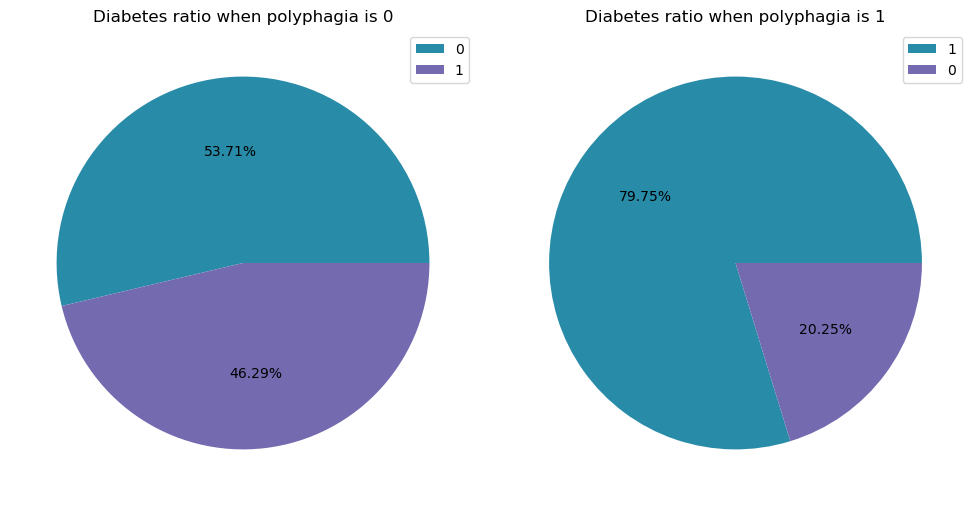

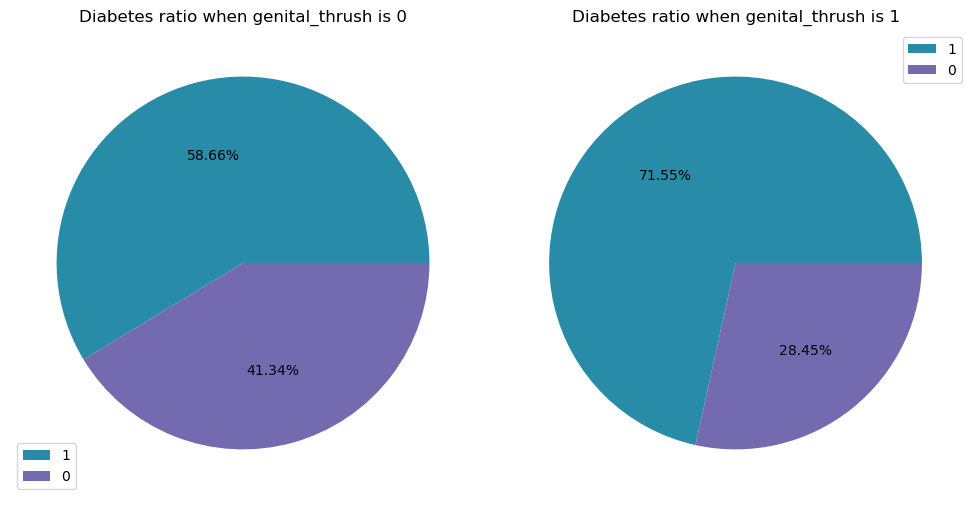

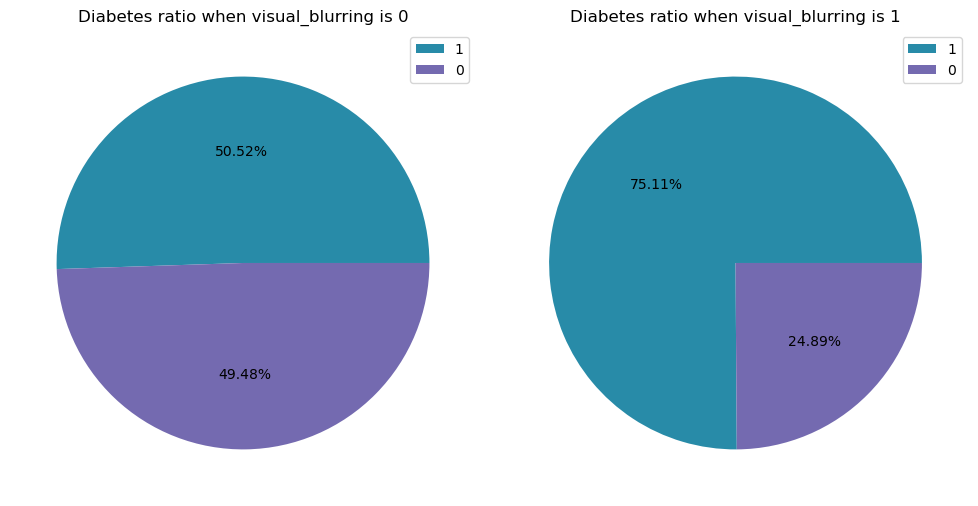

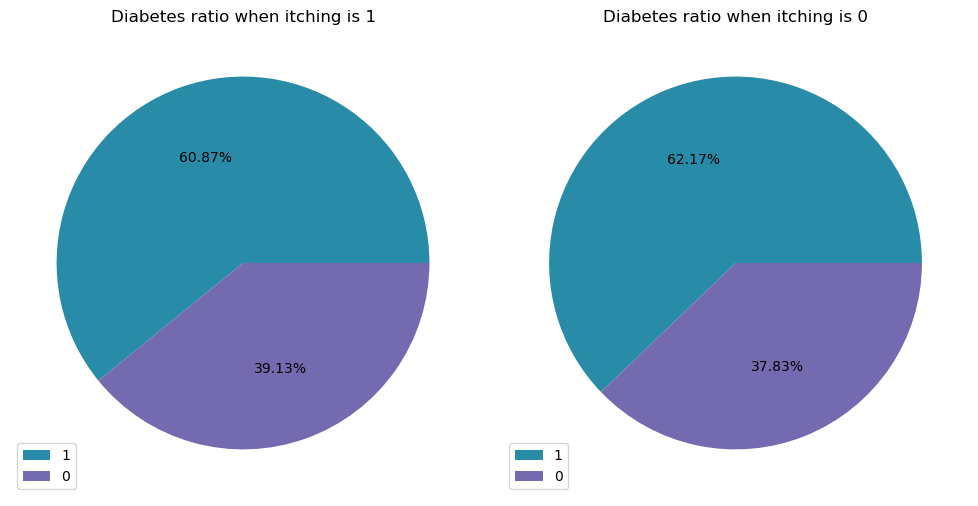

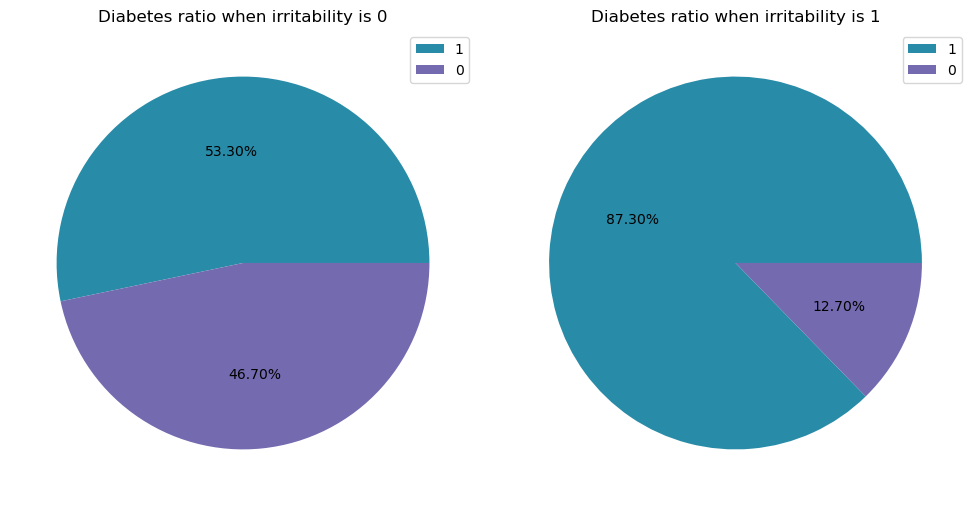

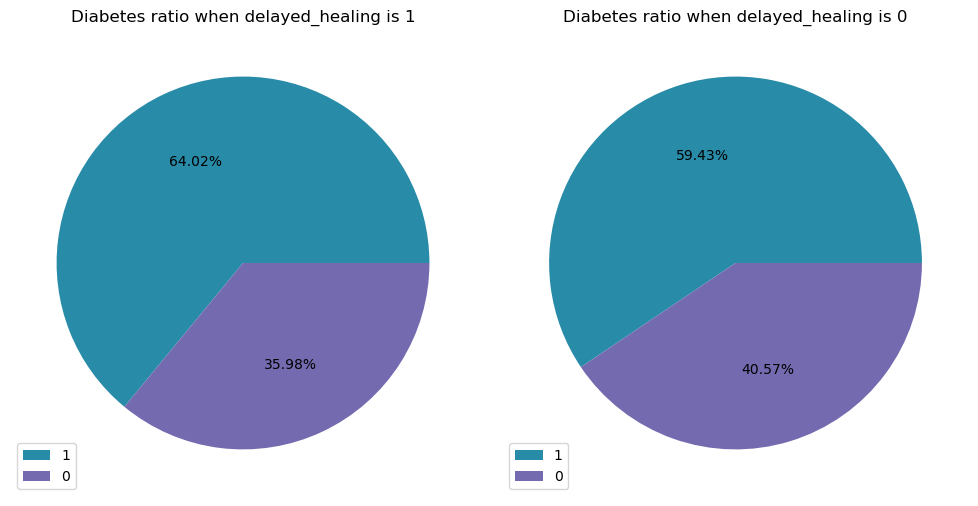

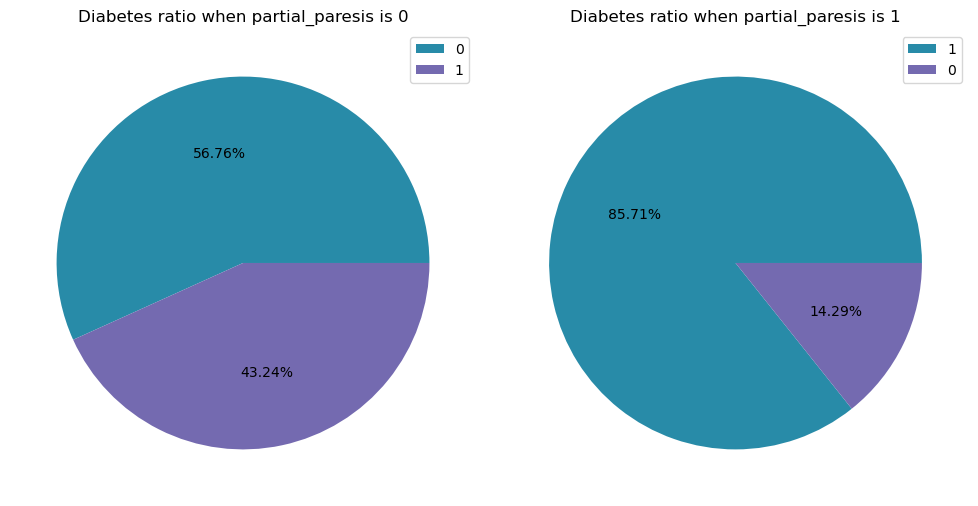

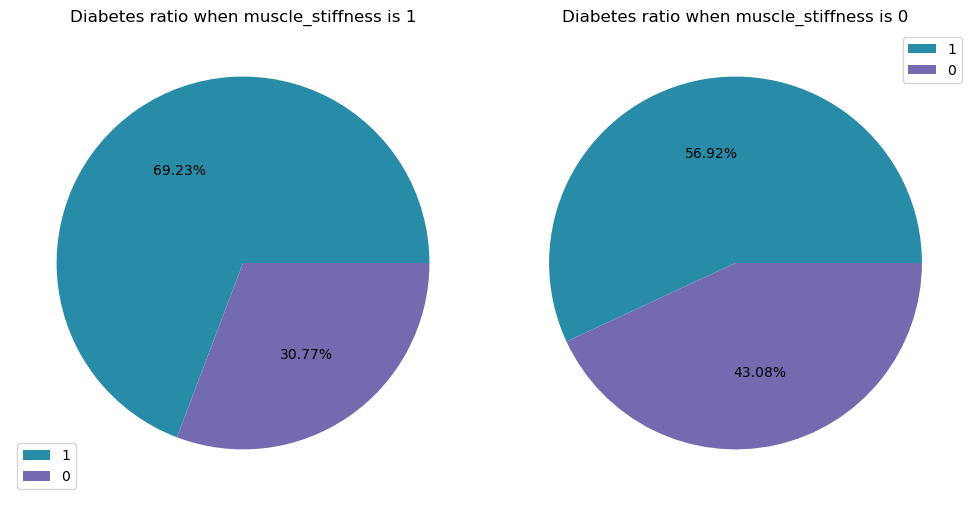

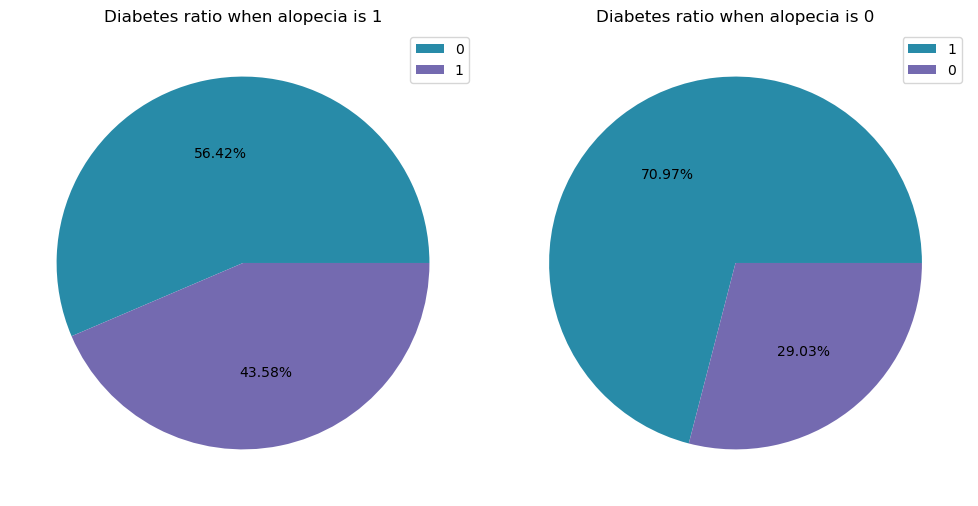

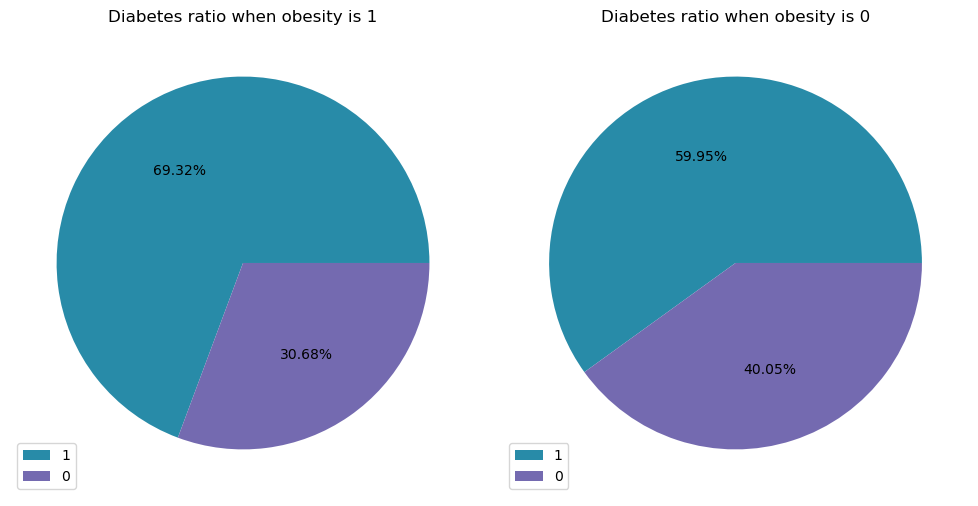

In [21]:
for i in df.columns[1:-1]:
    category(i)

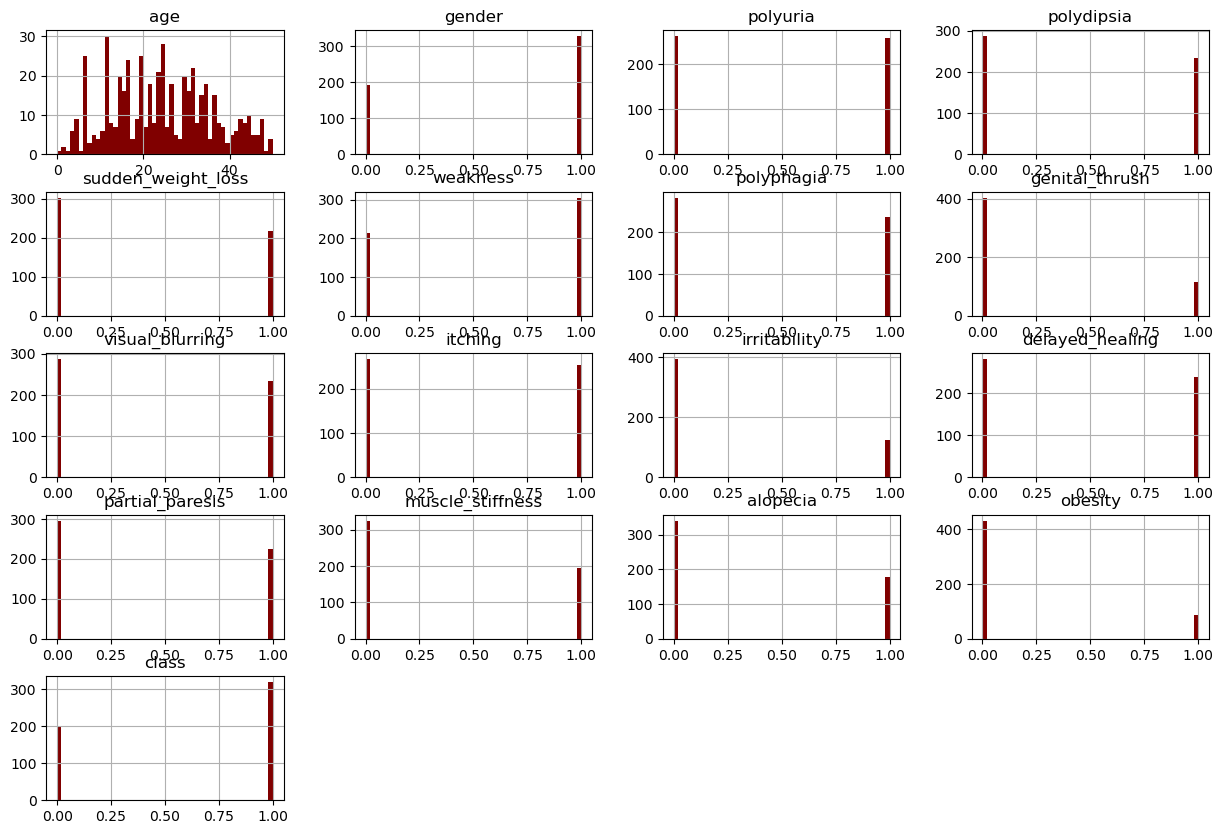

In [22]:
#plt.style.use()

# Plot histogram with colored bars
df.hist(figsize=(15, 10), bins=50, color='maroon')

plt.show()

In [23]:
df.columns

Index(['age', 'gender', 'polyuria', 'polydipsia', 'sudden_weight_loss',
       'weakness', 'polyphagia', 'genital_thrush', 'visual_blurring',
       'itching', 'irritability', 'delayed_healing', 'partial_paresis',
       'muscle_stiffness', 'alopecia', 'obesity', 'class'],
      dtype='object')

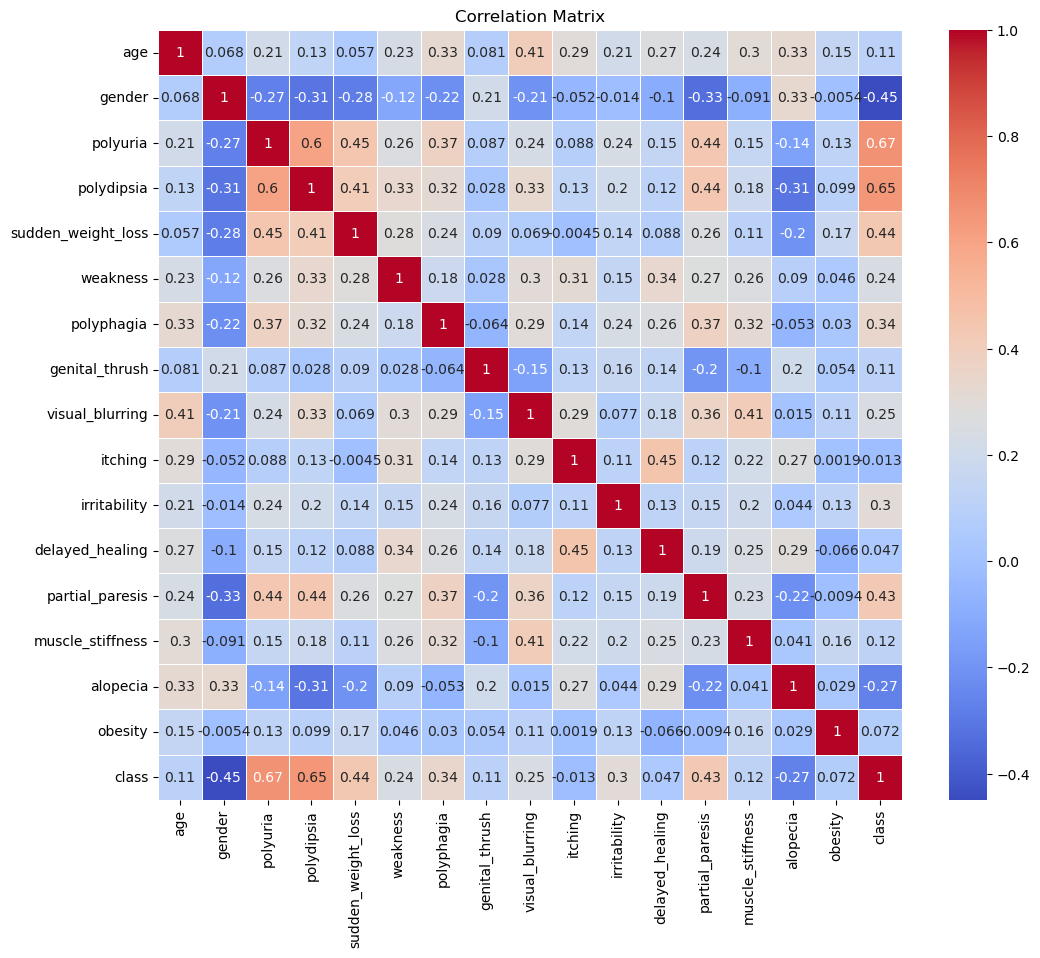

In [24]:

# List of features (you can adjust this if needed)
features = [
    'age', 'gender', 'polyuria', 'polydipsia', 'sudden_weight_loss',
    'weakness', 'polyphagia', 'genital_thrush', 'visual_blurring',
    'itching', 'irritability', 'delayed_healing', 'partial_paresis',
    'muscle_stiffness', 'alopecia', 'obesity', 'class'
]

# Select only the specified features
df = df[features]

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [25]:
col = ['Age','Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss',
       'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring',
       'Itching', 'Irritability', 'delayed healing', 'partial paresis',
       'muscle stiffness', 'Alopecia', 'Obesity']

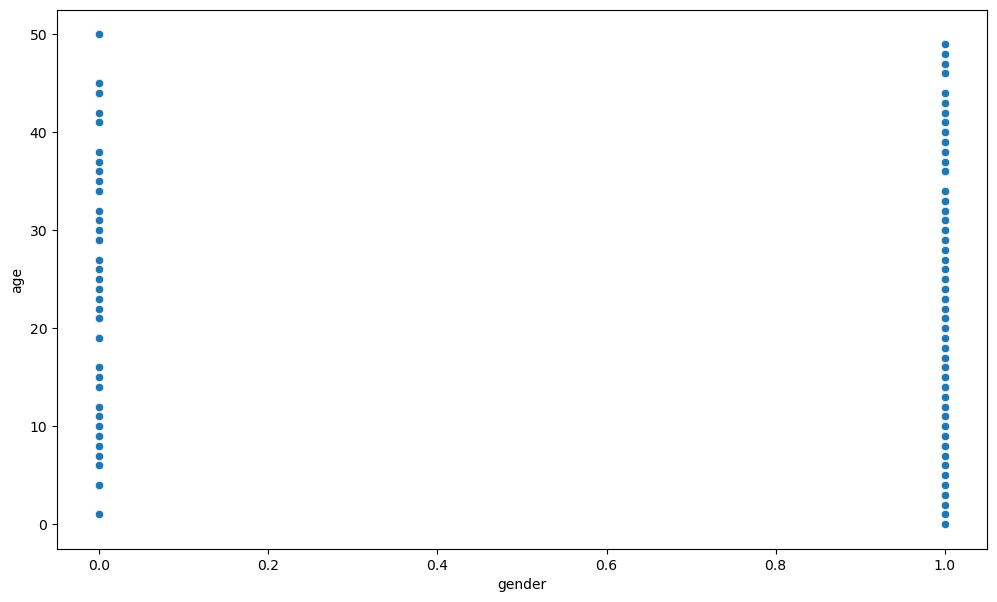

In [26]:
plt.figure(figsize=(12,7))
sns.scatterplot(data=df,y='age', x='gender')
plt.show()

In [27]:
#split dataset
X = df.drop('class', axis=1)
y = df['class']

In [28]:
y

0      1
1      1
2      1
3      1
4      1
      ..
515    1
516    1
517    1
518    0
519    0
Name: class, Length: 520, dtype: int32

# Train Test

In [29]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.22,random_state=0)

# Normalization

In [30]:
from sklearn.preprocessing import MinMaxScaler
scl = MinMaxScaler().fit(X_train)
X_train_norm = scl.transform(X_train)
X_test_norm = scl.transform(X_test)

# SVM

In [31]:
#SVC
svm=SVC(C=6, kernel="linear", random_state=0)
svm.fit(X_train,y_train)

SVC(C=6, kernel='linear', random_state=0)

In [32]:
#svm train accurecy
train_svm=svm.predict(X_train)
print(f"train accuracy :{accuracy_score(train_svm,y_train)}")


train accuracy :0.9407407407407408


In [33]:
#svm test accurecy

pre_svm=svm.predict(X_test)
print(f"test accuracy:{accuracy_score(pre_svm,y_test)}")


test accuracy:0.9391304347826087


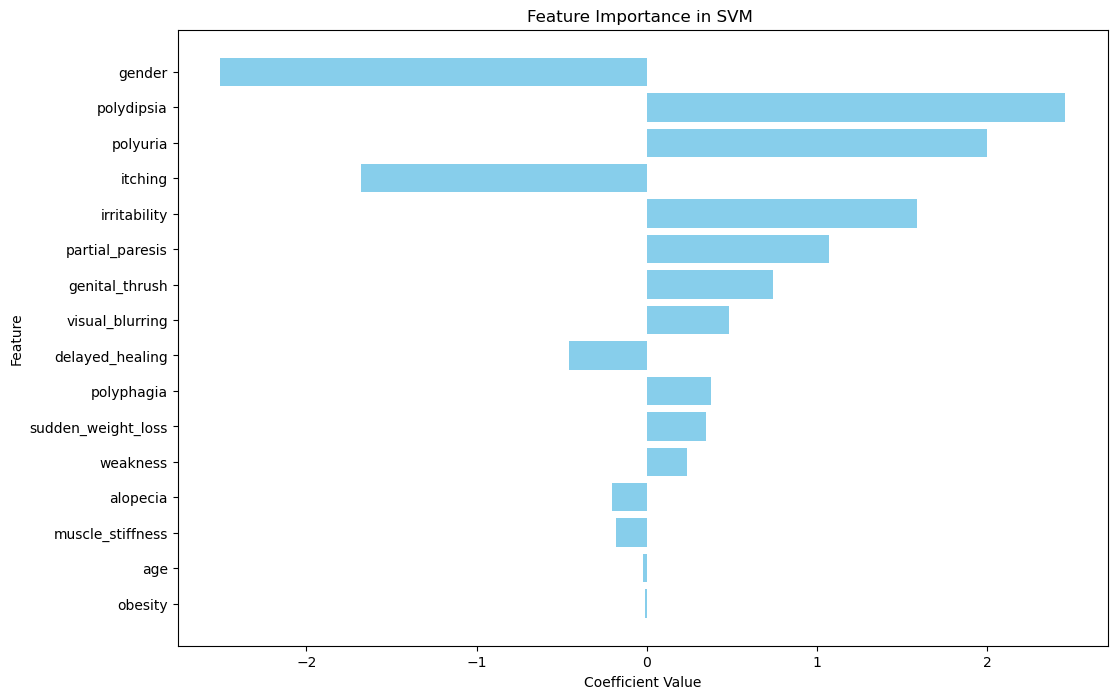

In [34]:
feature_names = ['age', 'gender', 'polyuria', 'polydipsia', 'sudden_weight_loss', 'weakness', 
                 'polyphagia', 'genital_thrush', 'visual_blurring', 'itching', 'irritability', 
                 'delayed_healing', 'partial_paresis', 'muscle_stiffness', 'alopecia', 'obesity', 'class']
# Retrieve the coefficients of the logistic regression model
coefficients = svm.coef_[0]

# Create a DataFrame to hold the feature names and their corresponding coefficients
feature_importance = pd.DataFrame({'Feature': feature_names[:-1], 'Coefficient': coefficients})

# Sort the DataFrame by the absolute value of the coefficients
feature_importance['Absolute_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Absolute_Coefficient', ascending=False)

# Plot the feature importance
plt.figure(figsize=(12, 8))
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'], color='skyblue')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Feature Importance in SVM ')
plt.gca().invert_yaxis()  # Invert the y-axis to have the most important feature on top
plt.show()

In [35]:
print(classification_report(pre_svm,y_test))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92        44
           1       0.97      0.93      0.95        71

    accuracy                           0.94       115
   macro avg       0.93      0.94      0.94       115
weighted avg       0.94      0.94      0.94       115



In [36]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Your SVM model
svm = SVC(C=6, kernel="linear", random_state=0)

# Perform cross-validation
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)  # 10-fold cross-validation
cross_val_scores = cross_val_score(svm, X_train, y_train, cv=kfold, scoring='accuracy')

print(f"Cross-validation accuracies: {cross_val_scores}")
print(f"Mean cross-validation accuracy: {cross_val_scores.mean()}")
print(f"Standard deviation of cross-validation accuracy: {cross_val_scores.std()}")

# Fit the model on the entire training set and evaluate on the test set
svm.fit(X_train, y_train)
train_svm = svm.predict(X_train)
print(f"Train accuracy: {accuracy_score(train_svm, y_train)}")
pre_svm = svm.predict(X_test)
print(f"Test accuracy: {accuracy_score(pre_svm, y_test)}")


Cross-validation accuracies: [0.97560976 1.         0.92682927 0.90243902 0.85365854 0.975
 0.825      0.95       0.85       0.925     ]
Mean cross-validation accuracy: 0.9183536585365853
Standard deviation of cross-validation accuracy: 0.05665382344455118
Train accuracy: 0.9407407407407408
Test accuracy: 0.9391304347826087


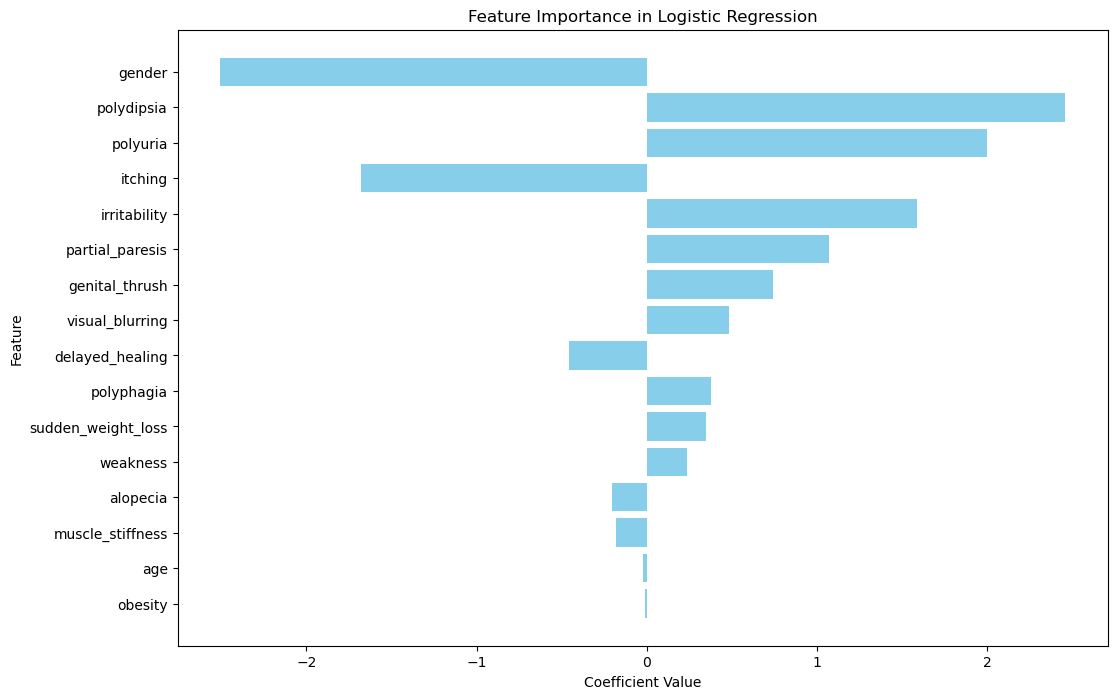

In [37]:


# Retrieve the coefficients of the logistic regression model
coefficients = svm.coef_[0]

# Create a DataFrame to hold the feature names and their corresponding coefficients
feature_importance = pd.DataFrame({'Feature': feature_names[:-1], 'Coefficient': coefficients})

# Sort the DataFrame by the absolute value of the coefficients
feature_importance['Absolute_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Absolute_Coefficient', ascending=False)

# Plot the feature importance
plt.figure(figsize=(12, 8))
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'], color='skyblue')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Feature Importance in Logistic Regression')
plt.gca().invert_yaxis()  # Invert the y-axis to have the most important feature on top
plt.show()

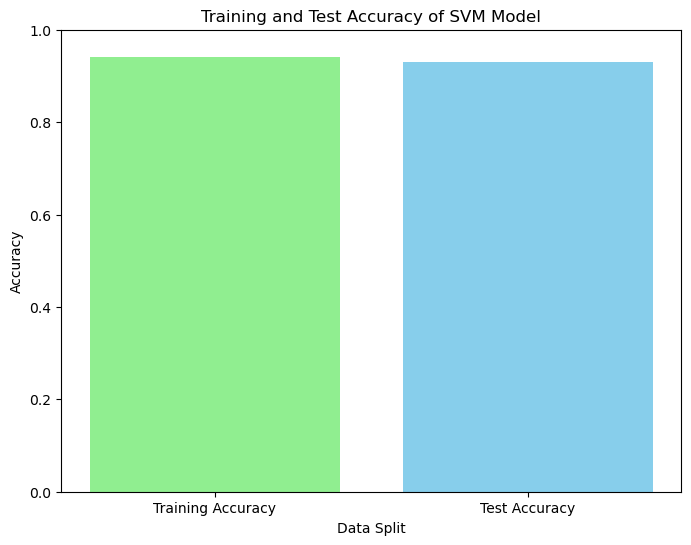

In [38]:
import matplotlib.pyplot as plt

# Given accuracies
train_accuracy = 0.94
test_accuracy = 0.93

# Labels and values
labels = ['Training Accuracy', 'Test Accuracy']
values = [train_accuracy, test_accuracy]

# Plotting the bar plot
plt.figure(figsize=(8, 6))
plt.bar(labels, values, color=['lightgreen', 'skyblue'])
plt.ylim(0, 1)  # Setting the y-axis limits to range from 0 to 1
plt.xlabel('Data Split')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracy of SVM Model')
plt.show()


X_train shape: (405, 16)
y_train shape: (405,)
X_test shape: (115, 16)
y_test shape: (115,)
X_train columns: Index(['age', 'gender', 'polyuria', 'polydipsia', 'sudden_weight_loss',
       'weakness', 'polyphagia', 'genital_thrush', 'visual_blurring',
       'itching', 'irritability', 'delayed_healing', 'partial_paresis',
       'muscle_stiffness', 'alopecia', 'obesity'],
      dtype='object')
X_test columns: Index(['age', 'gender', 'polyuria', 'polydipsia', 'sudden_weight_loss',
       'weakness', 'polyphagia', 'genital_thrush', 'visual_blurring',
       'itching', 'irritability', 'delayed_healing', 'partial_paresis',
       'muscle_stiffness', 'alopecia', 'obesity'],
      dtype='object')


C:\Users\user\AppData\Local\Temp\ipykernel_8032\2709069804.py:33: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
C:\Users\user\AppData\Local\Temp\ipykernel_8032\2709069804.py:33: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
C:\Users\user\AppData\Local\Temp\ipykernel_8032\2709069804.py:33: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
C:\Users\user\AppData\Local\Temp\ipykernel_8032\2709069804.py:33: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
C:\Users\user\AppData\Local\Temp\ipykernel_8032\2709069804.py:33: DeprecationWarning: scipy.interp is deprecated and will be removed in 

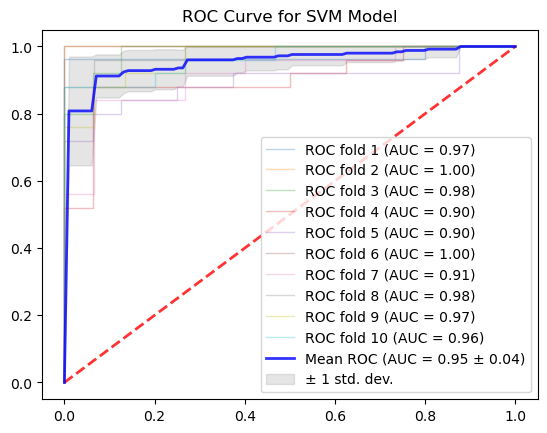

Train accuracy: 0.9407407407407408
Test accuracy: 0.9391304347826087


In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from scipy import interp

# Debugging: Print the shapes and columns of X and y
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Verify column names and indices
print(f"X_train columns: {X_train.columns}")
print(f"X_test columns: {X_test.columns}")

# SVM model with probability enabled
svm = SVC(C=6, kernel="linear", random_state=0, probability=True)

# Stratified K-Fold cross-validation
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

fig, ax = plt.subplots()

for i, (train, test) in enumerate(kfold.split(X_train, y_train)):
    svm.fit(X_train.iloc[train], y_train.iloc[train])  # Ensure you use iloc for indexing
    probas_ = svm.predict_proba(X_train.iloc[test])
    fpr, tpr, thresholds = roc_curve(y_train.iloc[test], probas_[:, 1])
    tprs.append(interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    ax.plot(fpr, tpr, lw=1, alpha=0.3, label=f'ROC fold {i+1} (AUC = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', alpha=0.8)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)
ax.plot(mean_fpr, mean_tpr, color='b',
        label=f'Mean ROC (AUC = {mean_auc:.2f} ± {std_auc:.2f})',
        lw=2, alpha=0.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=0.2,
                label='± 1 std. dev.')

ax.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05],
       title="ROC Curve for SVM Model")
ax.legend(loc="lower right")
plt.show()

# Fit the model on the entire training set and evaluate on the test set
svm.fit(X_train, y_train)
train_svm = svm.predict(X_train)
print(f"Train accuracy: {accuracy_score(train_svm, y_train)}")
pre_svm = svm.predict(X_test)
print(f"Test accuracy: {accuracy_score(pre_svm, y_test)}")


Train accuracy: 0.9407407407407408
Test accuracy: 0.9391304347826087


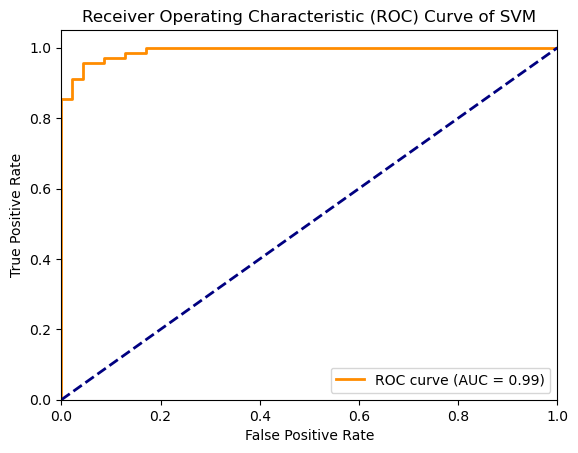

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize

# Ensure the data is properly loaded into X_train, X_test, y_train, y_test
# For this example, let's assume they are already loaded as pandas DataFrames

# Fit the SVM model
svm = SVC(C=6, kernel="linear", random_state=0, probability=True)
svm.fit(X_train, y_train)

# Predictions
train_svm = svm.predict(X_train)
print(f"Train accuracy: {accuracy_score(train_svm, y_train)}")
pre_svm = svm.predict(X_test)
print(f"Test accuracy: {accuracy_score(pre_svm, y_test)}")

# Calculate ROC curve and AUC
y_test_binarized = label_binarize(y_test, classes=[0, 1])
probas_ = svm.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test_binarized, probas_[:, 1])
roc_auc = auc(fpr, tpr)

# Plotting the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve of SVM')
plt.legend(loc="lower right")
plt.show()


In [41]:
svm = SVC(C=6, kernel="linear", random_state=0, probability=True)
svm.fit(X_train, y_train)


SVC(C=6, kernel='linear', probability=True, random_state=0)

In [42]:
train_svm = svm.predict(X_train)
print(f"Train accuracy: {accuracy_score(train_svm, y_train)}")
pre_svm = svm.predict(X_test)
print(f"Test accuracy: {accuracy_score(pre_svm, y_test)}")


Train accuracy: 0.9407407407407408
Test accuracy: 0.9391304347826087


In [43]:
y_test_binarized = label_binarize(y_test, classes=[0, 1])
probas_ = svm.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test_binarized, probas_[:, 1])
roc_auc = auc(fpr, tpr)


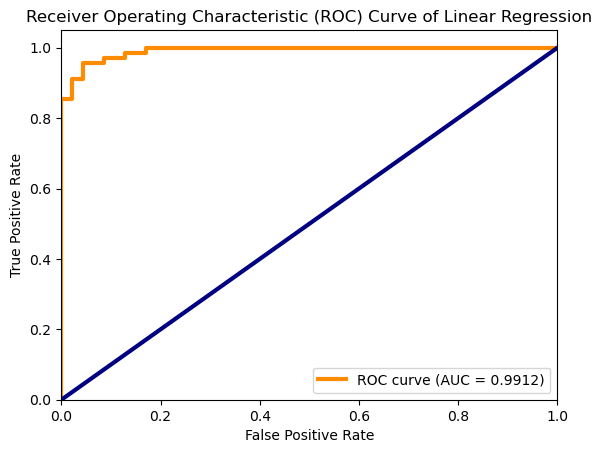

In [44]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=3, linestyle='-')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve of Linear Regression')
plt.legend(loc="lower right")
plt.show()


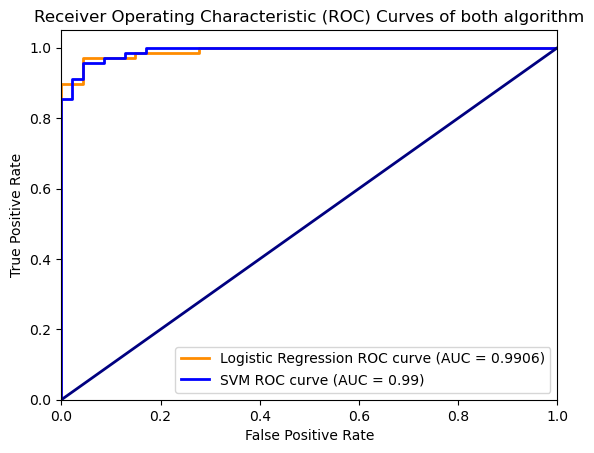

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize

# Logistic Regression Model
lg = LogisticRegression()
lg.fit(X_train, y_train)
probas_lg = lg.predict_proba(X_test)[:, 1]

# SVM Model with probability enabled
svm = SVC(C=6, kernel="linear", probability=True, random_state=0)
svm.fit(X_train, y_train)
probas_svm = svm.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC for Logistic Regression
fpr_lg, tpr_lg, _ = roc_curve(y_test, probas_lg)
roc_auc_lg = auc(fpr_lg, tpr_lg)

# Calculate ROC curve and AUC for SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, probas_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

# Plotting the ROC curves
plt.figure()
plt.plot(fpr_lg, tpr_lg, color='darkorange', lw=2, label=f'Logistic Regression ROC curve (AUC = {roc_auc_lg:.4f})')
plt.plot(fpr_svm, tpr_svm, color='blue', lw=2, label=f'SVM ROC curve (AUC = {roc_auc_svm:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='-')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves of both algorithm')
plt.legend(loc="lower right")
plt.show()


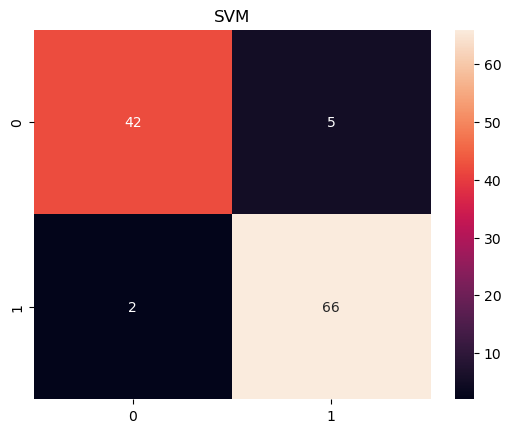

In [46]:
sns.heatmap(mt.confusion_matrix(y_test,svm.predict(X_test)),annot = True)
plt.title("SVM")
plt.show()

# Logisic Regression

In [47]:
#logistic regression
lg = LogisticRegression()
lg.fit(X_train,y_train)

LogisticRegression()

In [48]:
#train 
train_lg=lg.predict(X_train)
print(f"train accuracy :{accuracy_score(train_lg,y_train)}")


train accuracy :0.9358024691358025


In [49]:
pre_lg=lg.predict(X_test)
print(f"test accuracy:{accuracy_score(pre_lg,y_test)}")

test accuracy:0.9391304347826087


In [50]:
print(classification_report(pre_lg,y_test))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92        44
           1       0.97      0.93      0.95        71

    accuracy                           0.94       115
   macro avg       0.93      0.94      0.94       115
weighted avg       0.94      0.94      0.94       115



train accuracy: 0.9358024691358025
test accuracy: 0.9391304347826087


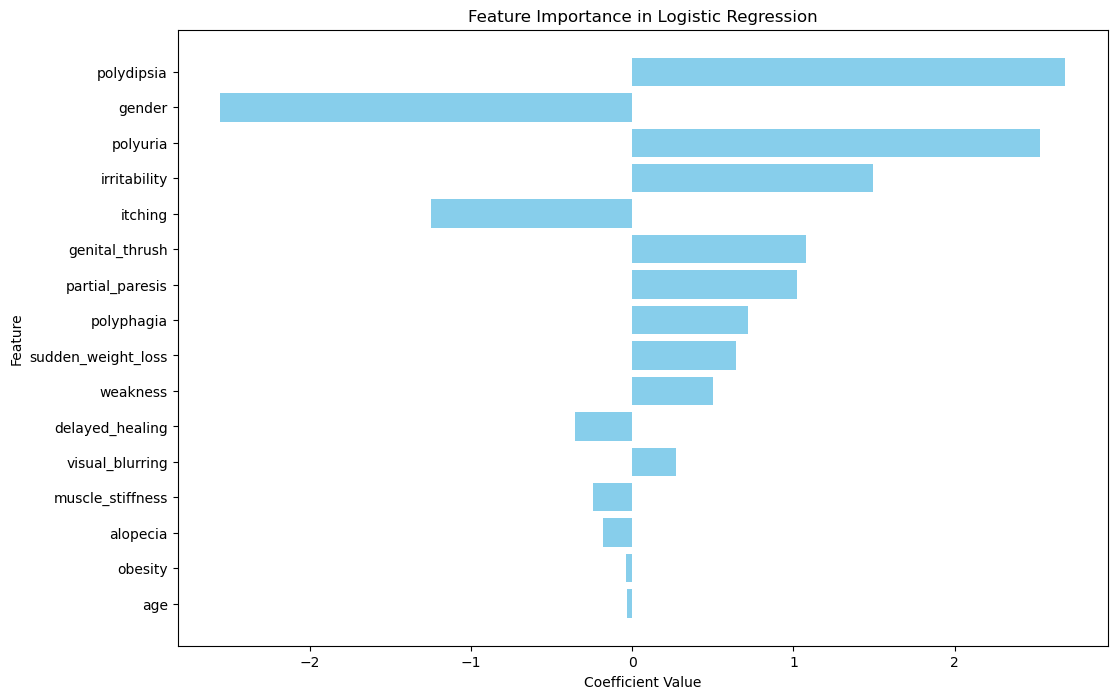

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Assuming X_train, X_test, y_train, y_test are numpy arrays

# Define feature names
feature_names = ['age', 'gender', 'polyuria', 'polydipsia', 'sudden_weight_loss', 'weakness', 
                 'polyphagia', 'genital_thrush', 'visual_blurring', 'itching', 'irritability', 
                 'delayed_healing', 'partial_paresis', 'muscle_stiffness', 'alopecia', 'obesity', 'class']

# Train the logistic regression model
lg = LogisticRegression(max_iter=1000)  # Increase max_iter if needed
lg.fit(X_train, y_train)

# Train accuracy
train_lg = lg.predict(X_train)
print(f"train accuracy: {accuracy_score(train_lg, y_train)}")

# Test accuracy
pre_lg = lg.predict(X_test)
print(f"test accuracy: {accuracy_score(pre_lg, y_test)}")

# Retrieve the coefficients of the logistic regression model
coefficients = lg.coef_[0]

# Create a DataFrame to hold the feature names and their corresponding coefficients
feature_importance = pd.DataFrame({'Feature': feature_names[:-1], 'Coefficient': coefficients})

# Sort the DataFrame by the absolute value of the coefficients
feature_importance['Absolute_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Absolute_Coefficient', ascending=False)

# Plot the feature importance
plt.figure(figsize=(12, 8))
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'], color='skyblue')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Feature Importance in Logistic Regression')
plt.gca().invert_yaxis()  # Invert the y-axis to have the most important feature on top
plt.show()


Train accuracy: 0.9358024691358025
Test accuracy: 0.9391304347826087


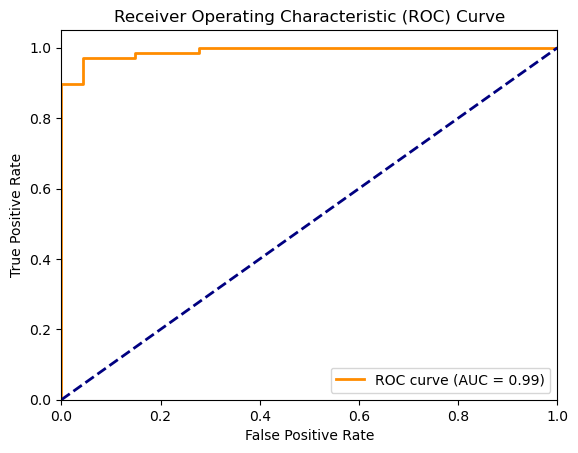

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import label_binarize

# Fit the Logistic Regression model
lg = LogisticRegression()
lg.fit(X_train, y_train)

# Predictions
train_lg = lg.predict(X_train)
print(f"Train accuracy: {accuracy_score(train_lg, y_train)}")
pre_lg = lg.predict(X_test)
print(f"Test accuracy: {accuracy_score(pre_lg, y_test)}")

# Calculate ROC curve and AUC
y_test_binarized = label_binarize(y_test, classes=[0, 1])
probas_ = lg.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test_binarized, probas_[:, 1])
roc_auc = auc(fpr, tpr)

# Plotting the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


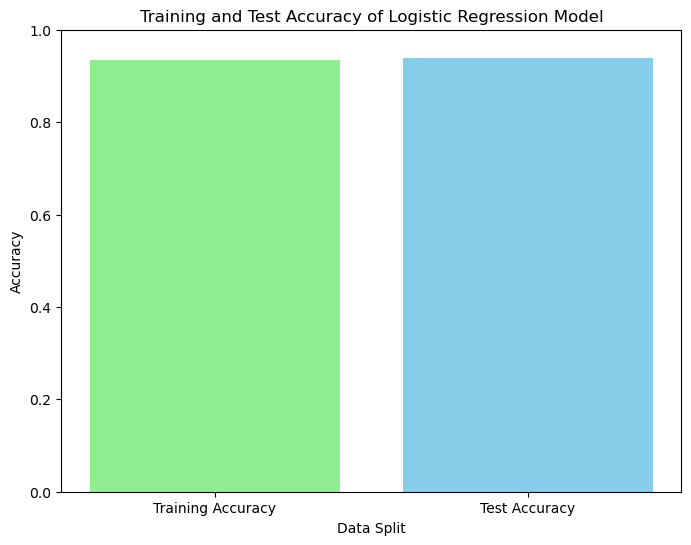

In [53]:
train_accuracy = 0.935
test_accuracy = 0.939

# Labels and values
labels = ['Training Accuracy', 'Test Accuracy']
values = [train_accuracy, test_accuracy]

# Plotting the bar plot
plt.figure(figsize=(8, 6))
plt.bar(labels, values, color=['lightgreen', 'skyblue'])
plt.ylim(0, 1)  # Setting the y-axis limits to range from 0 to 1
plt.xlabel('Data Split')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracy of Logistic Regression Model')
plt.show()

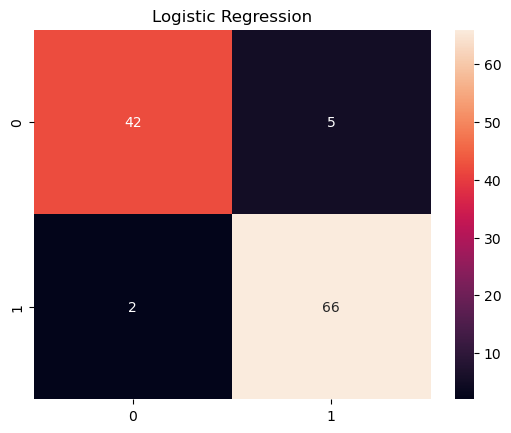

In [54]:
sns.heatmap(mt.confusion_matrix(y_test,lg.predict(X_test)),annot = True)
plt.title("Logistic Regression")
plt.show()

In [55]:
#test
pre_lg=lg.predict(X_test)
print(f"test accuracy:{accuracy_score(pre_lg,y_test)}")


test accuracy:0.9391304347826087


# Naive Bayes

In [56]:
#naive bayes

from sklearn.naive_bayes import GaussianNB

In [57]:
naive_bayes = GaussianNB()
naive_bayes.fit(X_train , y_train)

GaussianNB()

In [58]:
#train
train_nv=naive_bayes.predict(X_train)
print(f"train accuracy:{accuracy_score(train_nv,y_train)}")


train accuracy:0.8888888888888888


In [59]:
#test
pre_nv=naive_bayes.predict(X_test)
print(f"test accuracy:{accuracy_score(pre_nv,y_test)}")


test accuracy:0.9304347826086956


In [60]:
print(classification_report(pre_nv,y_test))


              precision    recall  f1-score   support

           0       0.85      0.98      0.91        41
           1       0.99      0.91      0.94        74

    accuracy                           0.93       115
   macro avg       0.92      0.94      0.93       115
weighted avg       0.94      0.93      0.93       115



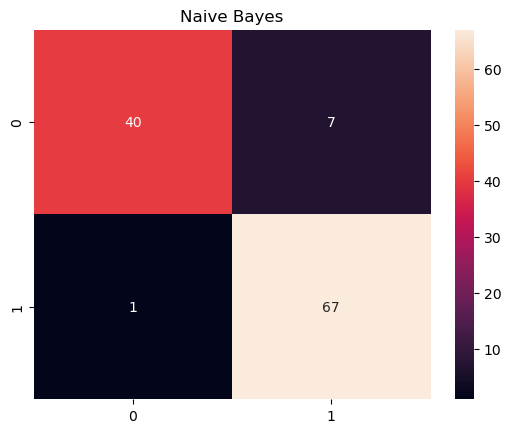

In [61]:
sns.heatmap(mt.confusion_matrix(y_test,naive_bayes.predict(X_test)),annot = True)
plt.title("Naive Bayes")
plt.show()

# XGBClassifier 

In [62]:
#!pip install xgboost





In [63]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(object='binary:logistic', random_state=42)
xgb_model.fit(X_train, y_train)

Y_pred_xgb = xgb_model.predict(X_test)

C:\Users\user\AppData\Roaming\Python\Python39\site-packages\xgboost\core.py:160: UserWarning: [21:14:08] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "object" } are not used.

  warnings.warn(smsg, UserWarning)


In [64]:
score_xgb = round(accuracy_score(Y_pred_xgb, y_test)*100,2)
print("The accuracy score achived using XGBoost is:" +str(score_xgb)+" %")

The accuracy score achived using XGBoost is:99.13 %


In [65]:
report_xgb = classification_report(y_test, Y_pred_xgb)
print("Classification Report for XGBoost Model:\n")
print(report_xgb)

Classification Report for XGBoost Model:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        47
           1       1.00      0.99      0.99        68

    accuracy                           0.99       115
   macro avg       0.99      0.99      0.99       115
weighted avg       0.99      0.99      0.99       115



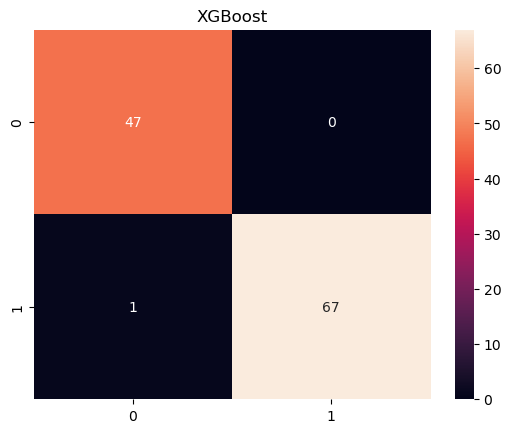

In [66]:
sns.heatmap(mt.confusion_matrix(y_test,xgb_model.predict(X_test)),annot = True)
plt.title("XGBoost")
plt.show()

# Random Forest

In [67]:
rf = RandomForestClassifier(criterion = 'gini',n_estimators=80,random_state=33)
rf.fit(X_train, y_train)
 

RandomForestClassifier(n_estimators=80, random_state=33)

In [68]:
train_rf=rf.predict(X_train)
print(f"train accuracy:{accuracy_score(train_rf,y_train)}")

train accuracy:1.0


In [69]:
pre_rf=rf.predict(X_test)
print(f"test accuracy:{accuracy_score(pre_rf,y_test)}")

test accuracy:0.991304347826087


In [70]:
print(classification_report(pre_rf,y_test))


              precision    recall  f1-score   support

           0       1.00      0.98      0.99        48
           1       0.99      1.00      0.99        67

    accuracy                           0.99       115
   macro avg       0.99      0.99      0.99       115
weighted avg       0.99      0.99      0.99       115



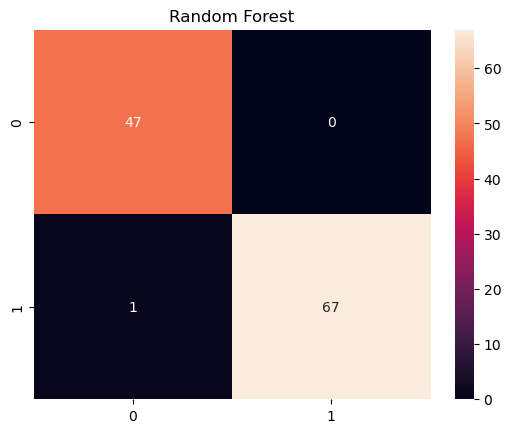

In [71]:
sns.heatmap(mt.confusion_matrix(y_test,rf.predict(X_test)),annot = True)
plt.title("Random Forest")
plt.show()

In [72]:
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)  # 10-fold cross-validation
cross_val_scores = cross_val_score(rf, X_train, y_train, cv=kfold, scoring='accuracy')

print(f"Cross-validation accuracies: {cross_val_scores}")
print(f"Mean cross-validation accuracy: {cross_val_scores.mean()}")
print(f"Standard deviation of cross-validation accuracy: {cross_val_scores.std()}")

# Fit the model on the entire training set and evaluate on the test set

Cross-validation accuracies: [0.97560976 1.         1.         0.95121951 0.95121951 1.
 0.975      1.         0.975      0.975     ]
Mean cross-validation accuracy: 0.9803048780487804
Standard deviation of cross-validation accuracy: 0.018302944276400165


# KNN


In [73]:
from sklearn.neighbors import KNeighborsClassifier

In [74]:
knn=KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [75]:
train_knn=knn.predict(X_train)
print(accuracy_score(train_knn,y_train))

0.9333333333333333


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


In [76]:
pre_knn=knn.predict(X_test)
print(accuracy_score(pre_knn,y_test))

0.9130434782608695


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


In [77]:
print(classification_report(pre_knn,y_test))


              precision    recall  f1-score   support

           0       1.00      0.82      0.90        57
           1       0.85      1.00      0.92        58

    accuracy                           0.91       115
   macro avg       0.93      0.91      0.91       115
weighted avg       0.93      0.91      0.91       115



C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdim

train accuracy: 0.908641975308642
test accuracy: 0.8695652173913043


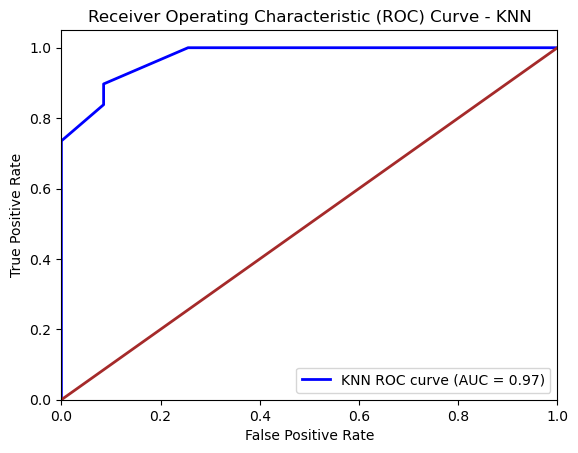

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.neighbors import KNeighborsClassifier

# Training the KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Train and test predictions
train_knn = knn.predict(X_train)
print(f"train accuracy: {accuracy_score(train_knn, y_train)}")
pre_knn = knn.predict(X_test)
print(f"test accuracy: {accuracy_score(pre_knn, y_test)}")

# Predict probabilities for the ROC curve
probas_knn = knn.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr_knn, tpr_knn, _ = roc_curve(y_test, probas_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)

# Plotting the ROC curve
plt.figure()
plt.plot(fpr_knn, tpr_knn, color='blue', lw=2, label=f'KNN ROC curve (AUC = {roc_auc_knn:.2f})')
plt.plot([0, 1], [0, 1], color='brown', lw=2, linestyle='-')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - KNN')
plt.legend(loc="lower right")
plt.show()


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


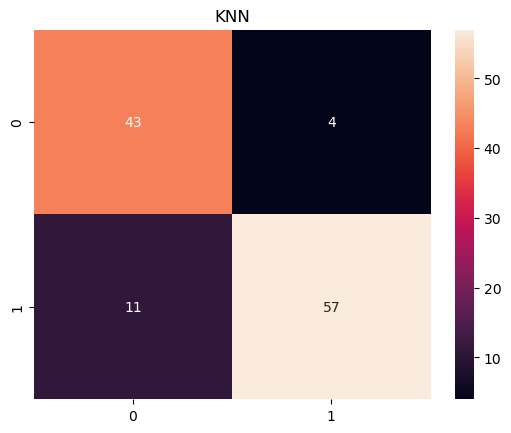

In [79]:
sns.heatmap(mt.confusion_matrix(y_test,knn.predict(X_test)),annot = True)
plt.title("KNN")
plt.show()

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


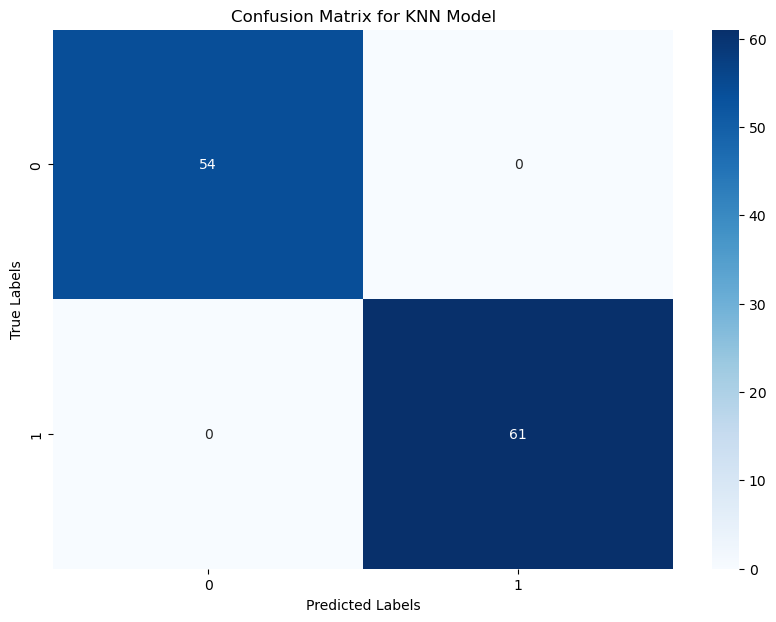

In [80]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(pre_knn, knn.predict(X_test))

# Plot the confusion matrix using seaborn
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for KNN Model')
plt.show()

In [81]:
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)  # 10-fold cross-validation
cross_val_scores = cross_val_score(knn, X_train, y_train, cv=kfold, scoring='accuracy')

print(f"Cross-validation accuracies: {cross_val_scores}")
print(f"Mean cross-validation accuracy: {cross_val_scores.mean()}")
print(f"Standard deviation of cross-validation accuracy: {cross_val_scores.std()}")

# Fit the model on the entire training set and evaluate on the test set

Cross-validation accuracies: [0.95121951 0.92682927 0.92682927 0.82926829 0.73170732 0.8
 0.725      0.85       0.825      0.85      ]
Mean cross-validation accuracy: 0.8415853658536585
Standard deviation of cross-validation accuracy: 0.0738347915456778


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdim

# Neural Network

In [82]:
!pip install tensorflow


Defaulting to user installation because normal site-packages is not writeable


In [83]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense


In [84]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=64, activation='relu', input_dim=X_train.shape[1]),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


C:\Users\user\AppData\Roaming\Python\Python39\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Fit the model

In [85]:
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5844 - loss: 1.2096 - val_accuracy: 0.4435 - val_loss: 0.7160
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5896 - loss: 0.6704 - val_accuracy: 0.6435 - val_loss: 0.6659
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7068 - loss: 0.5829 - val_accuracy: 0.8609 - val_loss: 0.5661
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7851 - loss: 0.5533 - val_accuracy: 0.7739 - val_loss: 0.5030
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7969 - loss: 0.4759 - val_accuracy: 0.9391 - val_loss: 0.4456
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8781 - loss: 0.4380 - val_accuracy: 0.8696 - val_loss: 0.4044
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8924 - loss: 0.4120 - val_accuracy: 0.8870 - val_loss: 0.3720
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9093 - loss: 0.3676 - val_accuracy: 0.9130 - val_loss

In [86]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9402 - loss: 0.2846 
Test Accuracy: 0.9391


In [87]:
train_loss, train_accuracy = model.evaluate(X_train, y_train)
print(f"Training Accuracy: {train_accuracy:.4f}")


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9109 - loss: 0.3049 
Training Accuracy: 0.9160


In [88]:
y_pred = model.predict(X_test)
y_pred_binary = (y_pred > 0.5).astype(int)  # Convert probabilities to binary predictions

print("Classification Report:")
print(classification_report(y_test, y_pred_binary))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92        47
           1       0.94      0.96      0.95        68

    accuracy                           0.94       115
   macro avg       0.94      0.94      0.94       115
weighted avg       0.94      0.94      0.94       115



Epoch 1/30


C:\Users\user\AppData\Roaming\Python\Python39\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5180 - loss: 0.7733 - val_accuracy: 0.5826 - val_loss: 0.6287
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6633 - loss: 0.5865 - val_accuracy: 0.6261 - val_loss: 0.5743
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7128 - loss: 0.5309 - val_accuracy: 0.6696 - val_loss: 0.5292
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7100 - loss: 0.4949 - val_accuracy: 0.8435 - val_loss: 0.4730
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8410 - loss: 0.4412 - val_accuracy: 0.8783 - val_loss: 0.4323
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8884 - loss: 0.4132 - val_accuracy: 0.8261 - val_loss: 0.4025
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8652 - loss: 0.3658 - val_accuracy: 0.8957 - val_loss: 0.3594
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9109 - loss: 0.3513 - val_accuracy: 0.8261 - val_loss: 0.3578
Ep

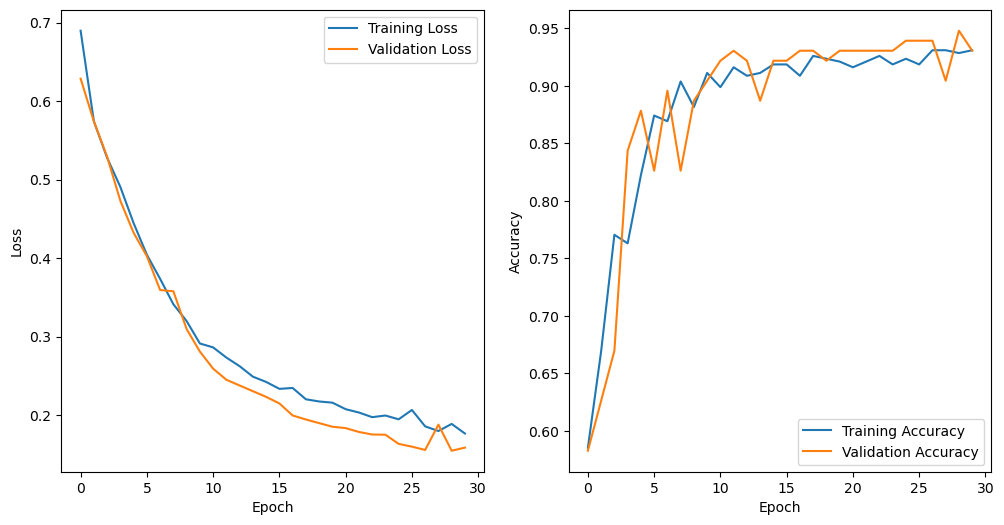

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping

# Assuming your dataset is already loaded in a DataFrame named df
# df = pd.read_csv('your_dataset.csv')

# Splitting the data into features (X) and target (y)
# Assuming the last column is the target variable
# X = df.iloc[:, :-1].values
# y = df.iloc[:, -1].values

# Example data split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.22, random_state=0)

# Standardizing the features
model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=64, activation='relu', input_dim=X_train.shape[1]),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Define the early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, verbose=1)

history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stopping])

# Plotting the training history
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


# Decision tree


In [90]:
clf = DecisionTreeClassifier(max_depth=3)  

In [91]:
# Train the model
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

In [92]:
# Make predictions
y_pred = clf.predict(X_test)

In [93]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.94


In [94]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92        47
           1       0.93      0.97      0.95        68

    accuracy                           0.94       115
   macro avg       0.94      0.93      0.94       115
weighted avg       0.94      0.94      0.94       115



Accuracy: 0.94


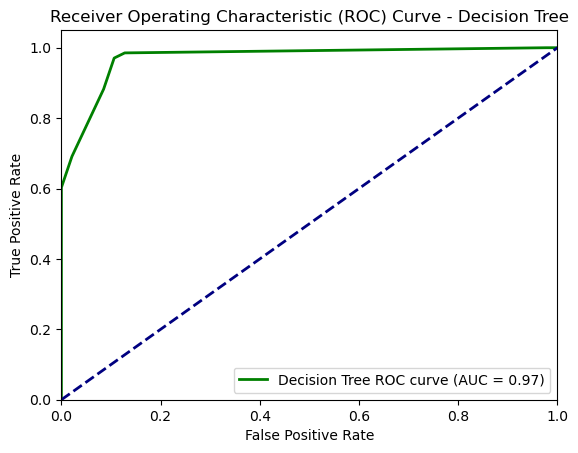

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(max_depth=3)  
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

# Predict probabilities for the ROC curve
probas_dt = clf.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr_dt, tpr_dt, _ = roc_curve(y_test, probas_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# Plotting the ROC curve
plt.figure()
plt.plot(fpr_dt, tpr_dt, color='green', lw=2, label=f'Decision Tree ROC curve (AUC = {roc_auc_dt:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Decision Tree')
plt.legend(loc="lower right")
plt.show()


SVM Train Accuracy: 0.9407407407407408
Logistic Regression Train Accuracy: 0.9358024691358025
Random Forest Train Accuracy: 1.0
KNN Train Accuracy: 0.908641975308642
Decision Tree Train Accuracy: 1.0


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


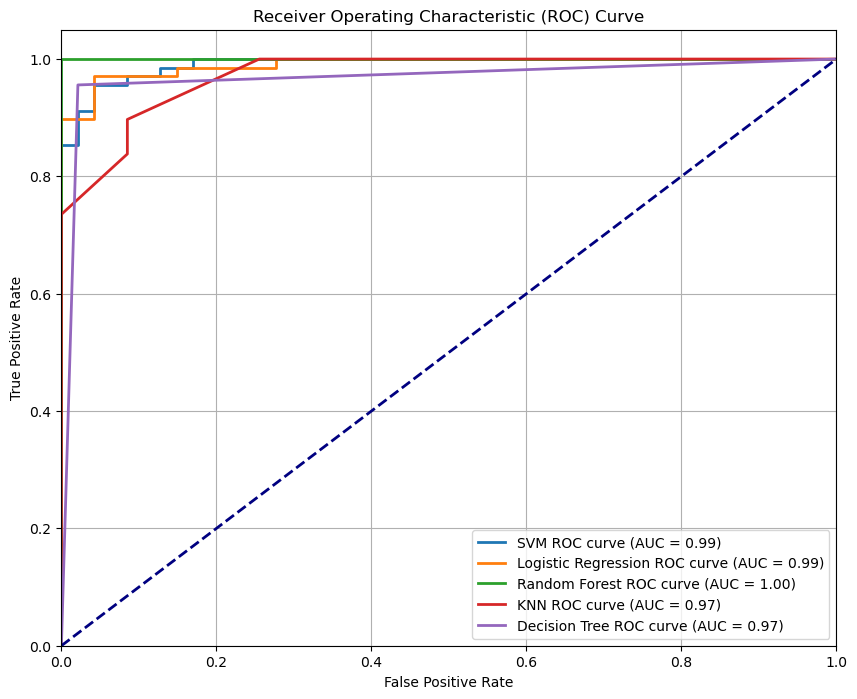

In [96]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Initialize classifiers
classifiers = {
    'SVM': SVC(C=6, kernel="linear", probability=True, random_state=0),
    'Logistic Regression': LogisticRegression(random_state=0),
    'Random Forest': RandomForestClassifier(n_estimators=80, random_state=33),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=0)
}

# Train and get probabilities for each classifier
plt.figure(figsize=(10, 8))
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    train_pred = clf.predict(X_train)
    print(f"{name} Train Accuracy: {accuracy_score(train_pred, y_train)}")
    
    # Calculate ROC curve and AUC
    if hasattr(clf, "predict_proba"):
        probas = clf.predict_proba(X_test)[:, 1]
    else:  # use decision function
        probas = clf.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, probas)
    roc_auc = auc(fpr, tpr)
    
    # Plot ROC curve
    plt.plot(fpr, tpr, lw=2, label=f'{name} ROC curve (AUC = {roc_auc:.2f})')

# Plot random guessing line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Set plot parameters
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


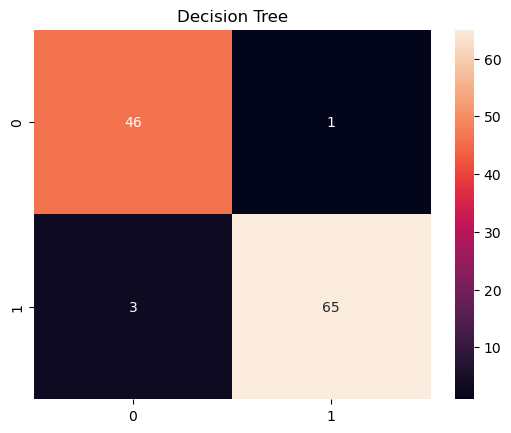

In [97]:
sns.heatmap(mt.confusion_matrix(y_test,clf.predict(X_test)),annot = True)
plt.title("Decision Tree")
plt.show()

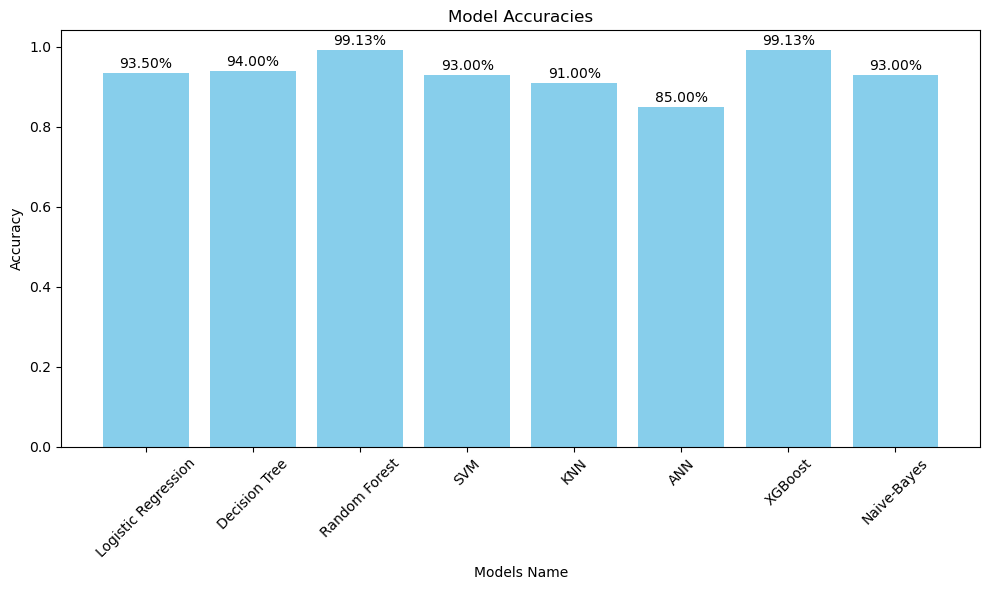

In [98]:
import matplotlib.pyplot as plt

# List of model names
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'KNN', 'ANN', 'XGBoost', 'Naive-Bayes']

# List of accuracies for each model
accuracies = [0.935, 0.94, 0.9913, 0.93, 0.91, 0.85, 0.9913, 0.93]  # Replace these with your actual accuracy values

# Create a bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color='skyblue')

# Add title and labels
plt.title('Model Accuracies')
plt.xlabel('Models Name')
plt.ylabel('Accuracy')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add text annotations
for bar, accuracy in zip(bars, accuracies):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{accuracy*100:.2f}%', ha='center', va='bottom')

# Show the plot
plt.tight_layout()
plt.show()


<AxesSubplot:>

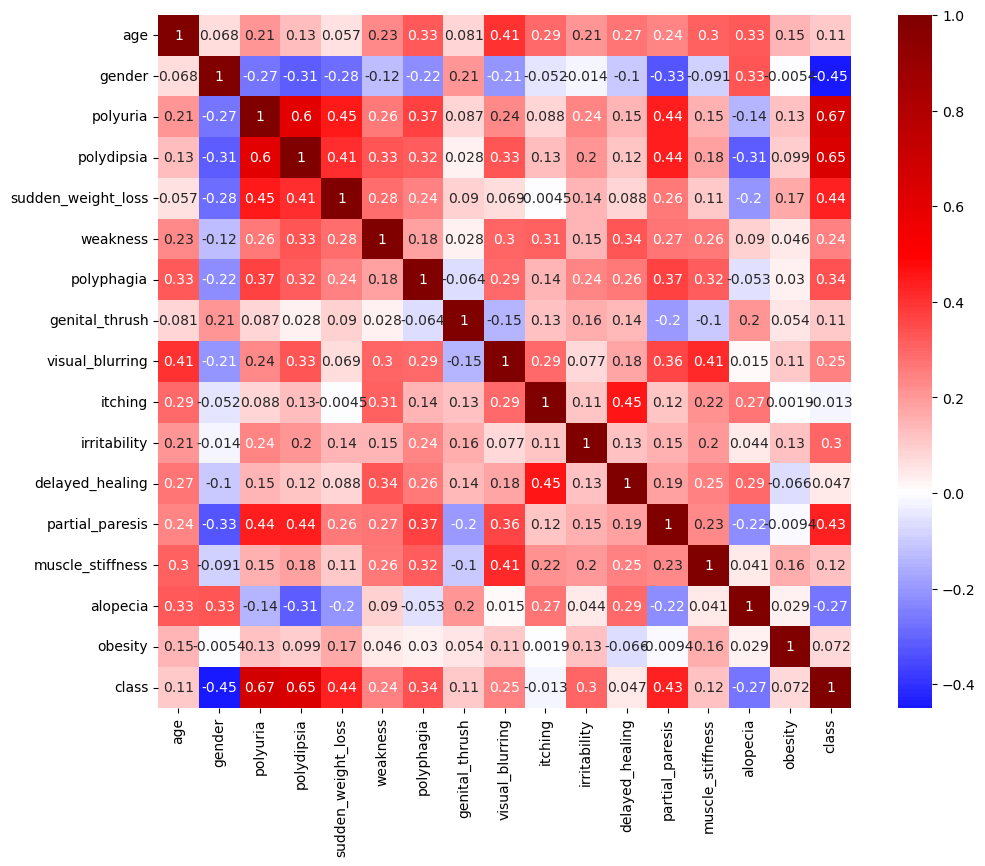

In [99]:
import matplotlib.pyplot as plot
import seaborn as sb

plot.figure(figsize = (12, 9))
corrMatrix =df.corr()
sb.heatmap(corrMatrix, square = True, annot = True, center = 0, cmap = 'seismic')

Training Accuracy: 0.8889
Test Accuracy: 0.9304


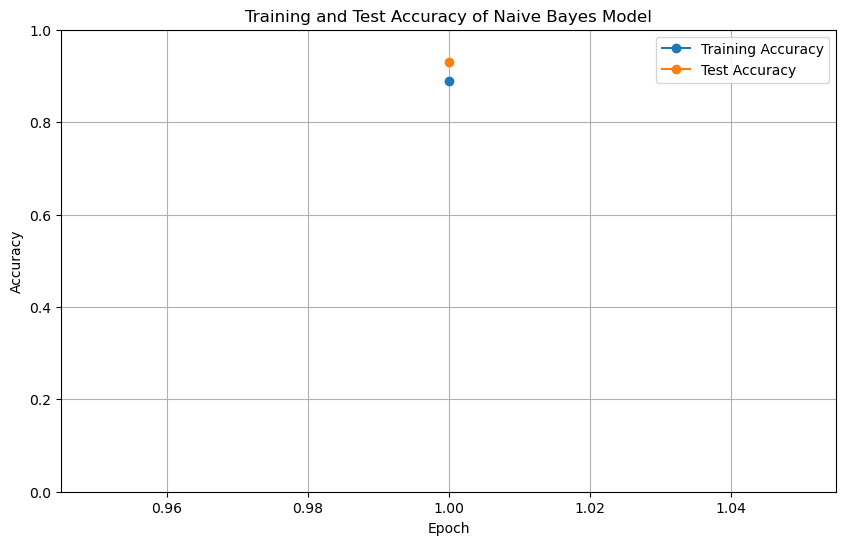

In [100]:
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Initialize the Naive Bayes model
naive_bayes = GaussianNB()

# Fit the model
naive_bayes.fit(X_train, y_train)

# Predict on training data
train_nv = naive_bayes.predict(X_train)
train_accuracy = accuracy_score(train_nv, y_train)

# Predict on test data
pre_nv = naive_bayes.predict(X_test)
test_accuracy = accuracy_score(pre_nv, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Simulating epoch-like behavior for Naive Bayes
# Since Naive Bayes does not train in epochs, we'll simulate a single-step accuracy tracking
epochs = [1]  # We use a single epoch since Naive Bayes trains in one go
train_accuracies = [train_accuracy]
test_accuracies = [test_accuracy]

# Plotting the accuracies
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_accuracies, label='Training Accuracy', marker='o')
plt.plot(epochs, test_accuracies, label='Test Accuracy', marker='o')
plt.ylim(0, 1)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracy of Naive Bayes Model')
plt.legend()
plt.grid(True)
plt.show()


# Proposed model


In [101]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib

# Assuming your dataset is loaded into a DataFrame called 'df'
# df = pd.read_csv('your_dataset.csv')  # Load your dataset

# Define the feature columns and target column
features = ['age', 'gender', 'polyuria', 'polydipsia', 'sudden_weight_loss', 'weakness',
            'polyphagia', 'genital_thrush', 'visual_blurring', 'itching', 'irritability',
            'delayed_healing', 'partial_paresis', 'muscle_stiffness', 'alopecia', 'obesity']
target = 'class'

# Split the data into training and testing sets
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.22, random_state=42)

# Train the Random Forest model
rf = RandomForestClassifier(criterion='gini', n_estimators=80, random_state=33)
rf.fit(X_train, y_train)

# Evaluate the model
train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)
print(f"Train accuracy: {accuracy_score(y_train, train_pred)}")
print(f"Test accuracy: {accuracy_score(y_test, test_pred)}")

# Save the trained model to a file
joblib.dump(rf, 'random_forest_model.pkl')


Train accuracy: 1.0
Test accuracy: 0.991304347826087


['random_forest_model.pkl']

In [102]:
import joblib
import numpy as np

# Load the trained Random Forest model
rf = joblib.load('random_forest_model.pkl')

# Function to predict diabetes
def predict_diabetes(user_input):
    # Ensure the user_input is in the correct format (2D array)
    user_input = np.array(user_input).reshape(1, -1)
    
    # Predict the class
    prediction = rf.predict(user_input)
    probability = rf.predict_proba(user_input)
    
    return prediction[0], probability

# Example user input
user_input = [55, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0]  # Replace with actual user data

# Predict diabetes for the user input
prediction, probability = predict_diabetes(user_input)
print(f"Prediction: {'Diabetic' if prediction == 1 else 'Non-diabetic'}")
print(f"Probability of each class: {probability}")


Prediction: Non-diabetic
Probability of each class: [[0.7 0.3]]


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


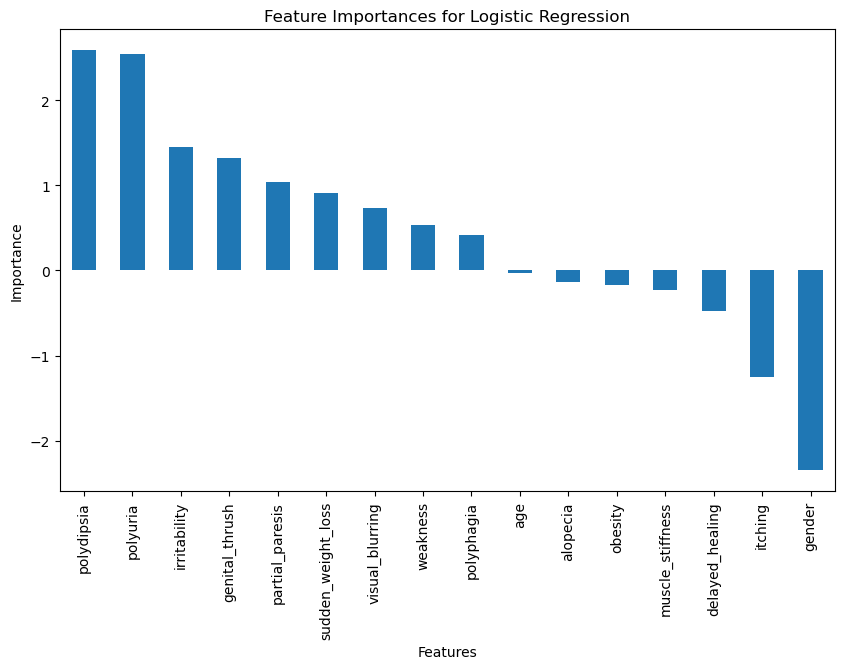

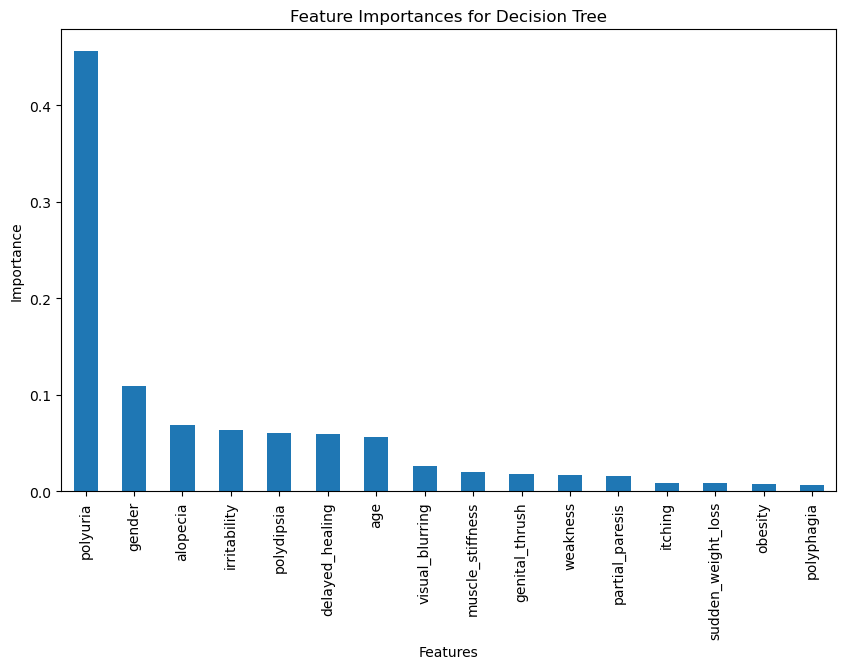

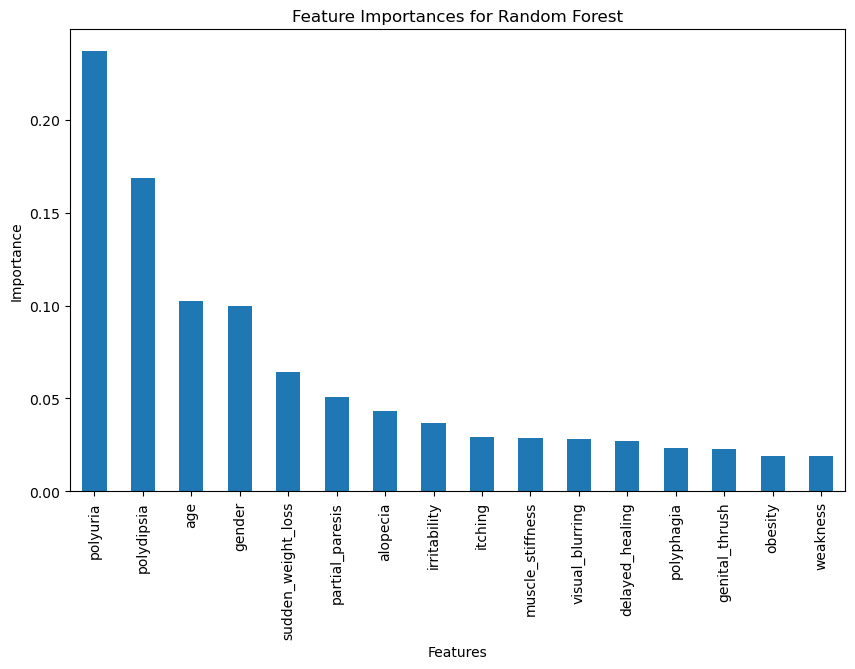

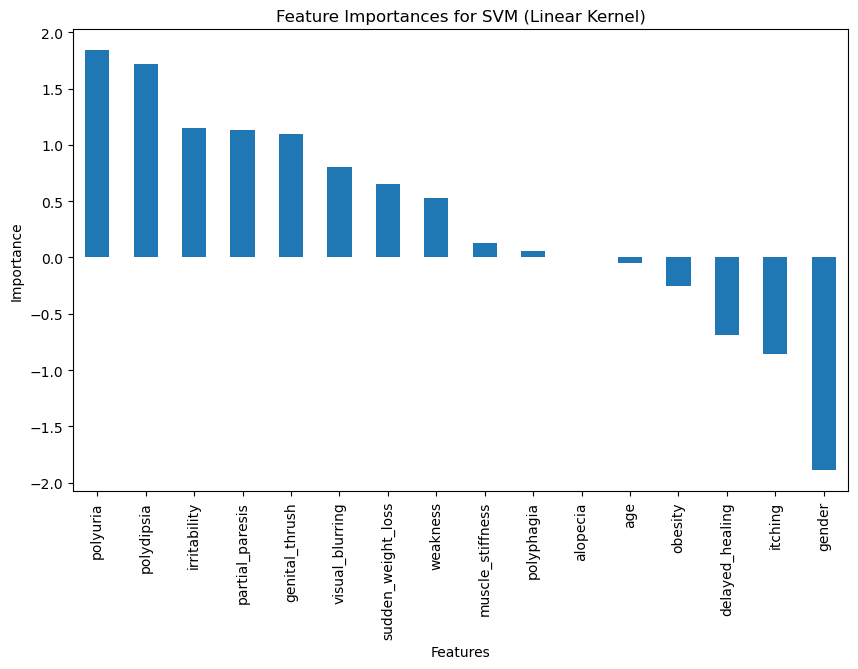

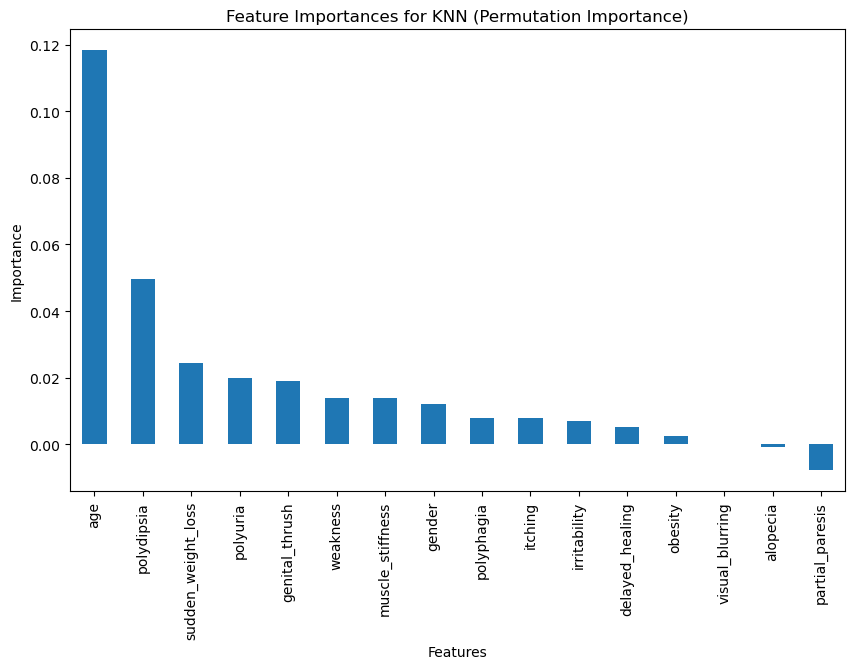

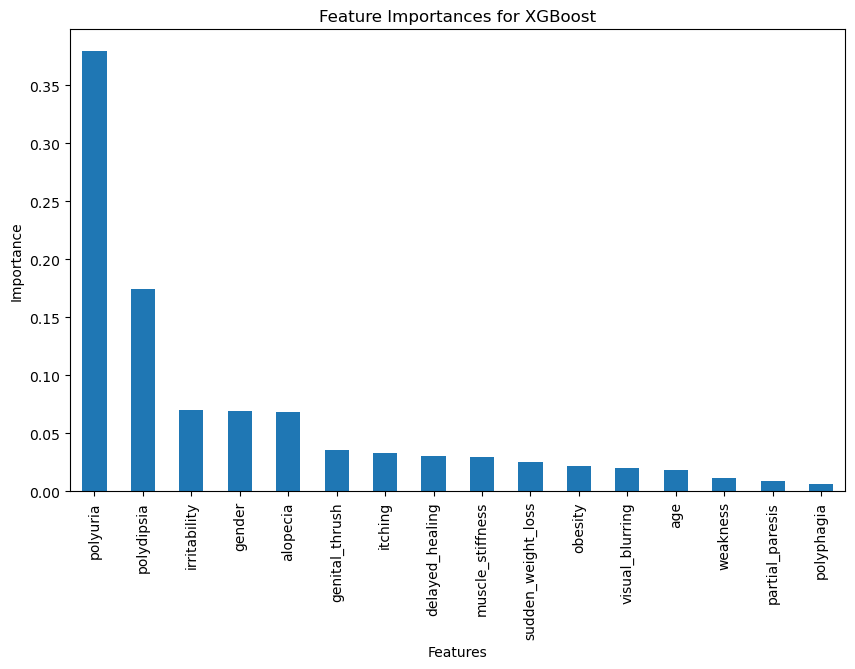

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance
import xgboost as xgb

# Assuming you have your dataset loaded in a DataFrame `df` and split into X and y
features = ['age', 'gender', 'polyuria', 'polydipsia', 'sudden_weight_loss',
            'weakness', 'polyphagia', 'genital_thrush', 'visual_blurring', 'itching',
            'irritability', 'delayed_healing', 'partial_paresis', 'muscle_stiffness', 
            'alopecia', 'obesity']

# Fit the models
lg = LogisticRegression()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier(criterion='gini', n_estimators=80, random_state=33)
svm = SVC(kernel='linear')
knn = KNeighborsClassifier()
xgb_model = xgb.XGBClassifier()

# Train the models
lg.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
svm.fit(X_train, y_train)
knn.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# Get feature importances
importance_lg = lg.coef_[0]
importance_dt = dt.feature_importances_
importance_rf = rf.feature_importances_
importance_svm = svm.coef_[0]
result_knn = permutation_importance(knn, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2)
importance_knn = result_knn.importances_mean
importance_xgb = xgb_model.feature_importances_

# Plot the feature importances
def plot_feature_importances(importances, model_name):
    feature_importances = pd.Series(importances, index=features)
    feature_importances = feature_importances.sort_values(ascending=False)
    feature_importances.plot(kind='bar', figsize=(10, 6))
    plt.title(f'Feature Importances for {model_name}')
    plt.xlabel('Features')
    plt.ylabel('Importance')
    plt.show()

# Plot for each model
plot_feature_importances(importance_lg, 'Logistic Regression')
plot_feature_importances(importance_dt, 'Decision Tree')
plot_feature_importances(importance_rf, 'Random Forest')
plot_feature_importances(importance_svm, 'SVM (Linear Kernel)')
plot_feature_importances(importance_knn, 'KNN (Permutation Importance)')
plot_feature_importances(importance_xgb, 'XGBoost')


In [104]:
import joblib
import pandas as pd

# Load the trained model
model = joblib.load('random_forest_model.pkl')

# Define the features
features = ['age', 'gender', 'polyuria', 'polydipsia', 'sudden_weight_loss',
            'weakness', 'polyphagia', 'genital_thrush', 'visual_blurring', 'itching',
            'irritability', 'delayed_healing', 'partial_paresis', 'muscle_stiffness', 
            'alopecia', 'obesity']

# Function to get user input
def get_user_input():
    user_data = {}
    for feature in features:
        user_data[feature] = input(f"Enter value for {feature}: ")
    return user_data

# Get input from user
user_input = get_user_input()

# Convert user input to DataFrame
user_input_df = pd.DataFrame([user_input])

# Ensure correct data types
for col in user_input_df.columns:
    user_input_df[col] = pd.to_numeric(user_input_df[col])

# Make prediction
prediction = model.predict(user_input_df[features])
prediction_proba = model.predict_proba(user_input_df[features])

# Add prediction to the input data
user_input_df['Prediction'] = prediction
user_input_df['Prediction'] = user_input_df['Prediction'].apply(lambda x: 'Diabetic' if x == 1 else 'Non-Diabetic')

# Print the result
print(user_input_df)


Enter value for age: 16
Enter value for gender: 0
Enter value for polyuria: 0
Enter value for polydipsia: 0
Enter value for sudden_weight_loss: 1
Enter value for weakness: 1
Enter value for polyphagia: 0
Enter value for genital_thrush: 0
Enter value for visual_blurring: 0
Enter value for itching: 1
Enter value for irritability: 1
Enter value for delayed_healing: 1
Enter value for partial_paresis: 0
Enter value for muscle_stiffness: 0
Enter value for alopecia: 1
Enter value for obesity: 1
   age  gender  polyuria  polydipsia  sudden_weight_loss  weakness  \
0   16       0         0           0                   1         1   

   polyphagia  genital_thrush  visual_blurring  itching  irritability  \
0           0               0                0        1             1   

   delayed_healing  partial_paresis  muscle_stiffness  alopecia  obesity  \
0                1                0                 0         1        1   

     Prediction  
0  Non-Diabetic  
